# London Housing Market: Comprehensive PhD-Level Analysis

**Datasets:** Monthly (1995–2020) · Yearly (1999–2019) · 45 areas · 33 boroughs  
**Scope:** Variable classification · EDA · Correlation · Clustering · Decomposition · SARIMA Forecasting

---
## Table of Contents
1. [Setup & Libraries](#1)
2. [Data Loading & Variable Classification](#2)
3. [Data Quality & Missing Values](#3)
4. [EDA — Monthly: Price Trends](#4)
5. [EDA — Monthly: Borough Comparison](#5)
6. [EDA — Monthly: Distributions, Seasonality & Decades](#6)
7. [EDA — Monthly: Crime Analysis](#7)
8. [EDA — Yearly: Salary Dynamics](#8)
9. [EDA — Yearly: Population, Jobs & Housing Stock](#9)
10. [EDA — Yearly: Wellbeing & Recycling](#10)
11. [Affordability Analysis (Price-to-Income)](#11)
12. [Borough Clustering (K-Means + PCA)](#12)
13. [Correlation Analysis](#13)
14. [Key Relationship Scatter Plots](#14)
15. [Time Series Decomposition & Stationarity](#15)
16. [ACF / PACF for Model Order Selection](#16)
17. [SARIMA Forecasting](#17)
18. [Key Insights Summary](#18)

In [9]:
!pip install seaborn
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa'
})
sns.set_theme(style='whitegrid', font_scale=0.95)
print('All libraries loaded.')

All libraries loaded.


## 2 — Data Loading & Variable Classification

| Variable | Dataset | Type | Description |
|---|---|---|---|
| `date` | Both | **Temporal** | Monthly/yearly timestamp |
| `area` | Both | **Nominal Categorical** | 45 areas: 33 London boroughs + UK regions |
| `code` | Both | **Nominal Categorical** | ONS geographic identifier (E09xxxxxx) |
| `borough_flag` | Both | **Binary Categorical** | 1 = London borough, 0 = regional aggregate |
| `average_price` | Monthly | **Quantitative Continuous** | Mean residential sale price (£) |
| `houses_sold` | Monthly | **Quantitative Discrete** | Transaction count per month |
| `no_of_crimes` | Monthly | **Quantitative Discrete** | Recorded offences |
| `median_salary` | Yearly | **Quantitative Continuous** | Median annual gross earnings (£) |
| `mean_salary` | Yearly | **Quantitative Continuous** | Mean annual gross earnings (£) — right-skewed |
| `life_satisfaction` | Yearly | **Quantitative Continuous** | ONS wellbeing score 0–10 |
| `recycling_pct` | Yearly | **Quantitative Continuous** | Household recycling rate (%) |
| `population_size` | Yearly | **Quantitative Discrete** | Resident population |
| `number_of_jobs` | Yearly | **Quantitative Discrete** | Total employment in borough |
| `area_size` | Yearly | **Quantitative Continuous** | Borough area (hectares) |
| `no_of_houses` | Yearly | **Quantitative Discrete** | Residential dwelling stock |

In [11]:
monthly = pd.read_csv('housing_in_london_monthly_variables.csv', parse_dates=['date'])
yearly  = pd.read_csv('housing_in_london_yearly_variables.csv',  parse_dates=['date'])

monthly = monthly.sort_values('date').reset_index(drop=True)
yearly  = yearly.sort_values(['area', 'date']).reset_index(drop=True)

monthly['year']  = monthly['date'].dt.year
monthly['month'] = monthly['date'].dt.month
yearly['year']   = yearly['date'].dt.year

# pandas 3.0 reads some CSV columns as StringDtype — coerce to float
for col in ['mean_salary', 'recycling_pct']:
    yearly[col] = pd.to_numeric(yearly[col], errors='coerce')

print('MONTHLY DATASET')
print(f'  Shape     : {monthly.shape}')
print(f'  Date range: {monthly.date.min().date()} to {monthly.date.max().date()}')
print(f'  Areas     : {monthly.area.nunique()} unique')
print(f'  Boroughs  : {monthly[monthly.borough_flag==1].area.nunique()} London boroughs')
print(monthly.dtypes.to_string())

print('\nYEARLY DATASET')
print(f'  Shape     : {yearly.shape}')
print(f'  Date range: {yearly.date.min().date()} to {yearly.date.max().date()}')
print(f'  Areas     : {yearly.area.nunique()} unique')
print(yearly.dtypes.to_string())

print('\nMONTHLY — Descriptive Statistics:')
monthly[['average_price', 'houses_sold', 'no_of_crimes']].describe().round(1)

MONTHLY DATASET
  Shape     : (13549, 9)
  Date range: 1995-01-01 to 2020-01-01
  Areas     : 45 unique
  Boroughs  : 33 London boroughs
date             datetime64[ns]
area                     object
average_price             int64
code                     object
houses_sold             float64
no_of_crimes            float64
borough_flag              int64
year                      int32
month                     int32

YEARLY DATASET
  Shape     : (1071, 13)
  Date range: 1999-12-01 to 2019-12-01
  Areas     : 51 unique
code                         object
area                         object
date                 datetime64[ns]
median_salary               float64
life_satisfaction           float64
mean_salary                 float64
recycling_pct               float64
population_size             float64
number_of_jobs              float64
area_size                   float64
no_of_houses                float64
borough_flag                  int64
year                          int32

MO

,average_price,houses_sold,no_of_crimes
count,13549.0,13455.0,7439.0
mean,263519.7,3894.0,2158.4
std,187617.5,12114.4,902.1
min,40722.0,2.0,0.0
25%,132380.0,247.0,1623.0
50%,222919.0,371.0,2132.0
75%,336843.0,3146.0,2582.0
max,1463378.0,132163.0,7461.0


In [12]:
print('YEARLY — Descriptive Statistics:')
yearly[['median_salary','mean_salary','life_satisfaction','recycling_pct','population_size','number_of_jobs']].describe().round(1)

YEARLY — Descriptive Statistics:


,median_salary,mean_salary,life_satisfaction,recycling_pct,population_size,number_of_jobs
count,1049.0,1054.0,352.0,859.0,1018.0,931.0
mean,27977.8,34474.2,7.5,26.9,6042576.5,3188094.5
std,6412.8,11002.8,0.2,12.9,15268096.6,8058302.2
min,15684.0,18351.0,7.0,0.0,6581.0,47000.0
25%,23857.0,28398.8,7.4,17.0,224345.8,94500.0
50%,27441.0,32374.5,7.5,27.0,294603.5,157000.0
75%,30932.0,37159.2,7.6,37.0,4630098.5,2217000.0
max,61636.0,90842.0,8.0,55.0,66435550.0,35750000.0


## 3 — Data Quality & Missing Values

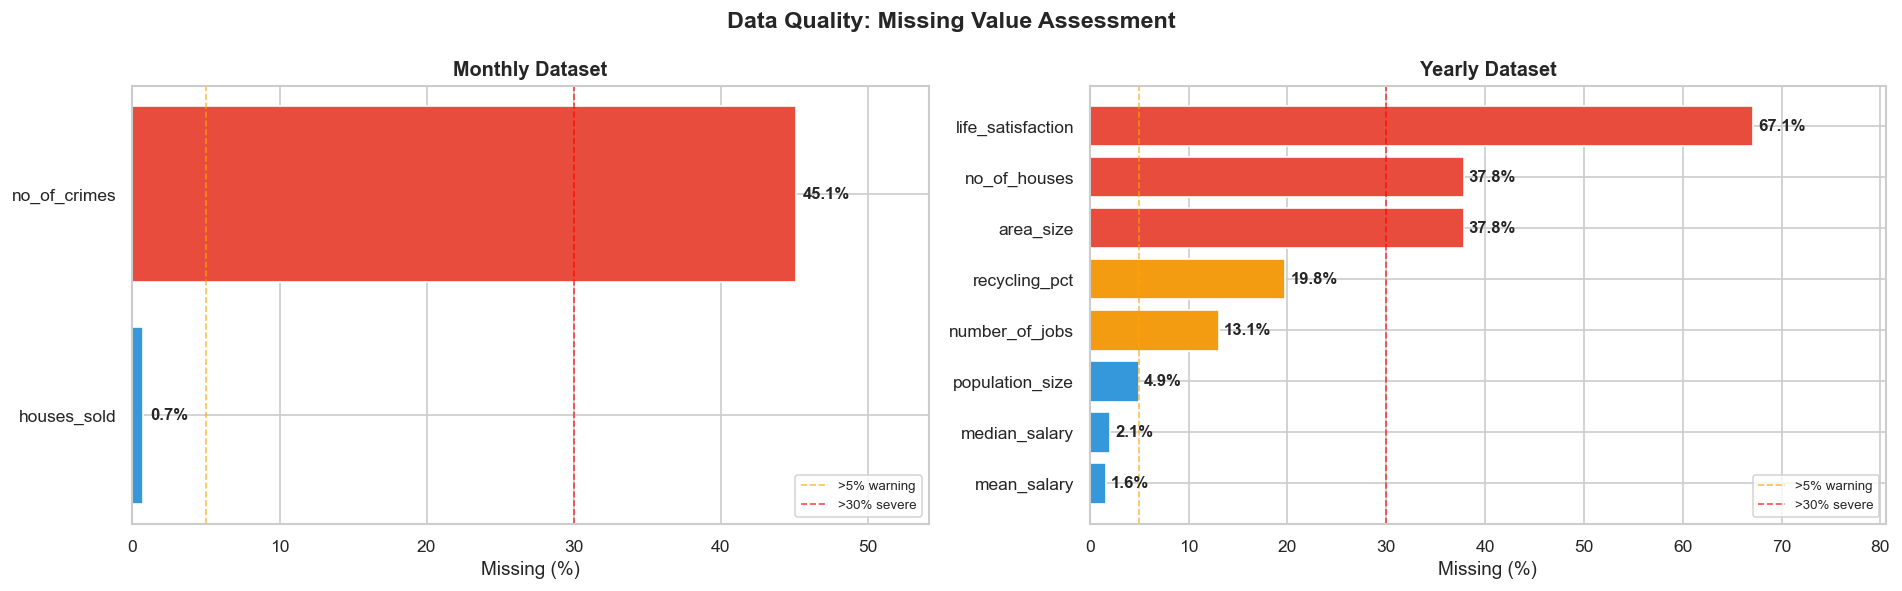

Missing value counts:
MONTHLY: {'date': 0, 'area': 0, 'average_price': 0, 'code': 0, 'houses_sold': 94, 'no_of_crimes': 6110, 'borough_flag': 0, 'year': 0, 'month': 0}
YEARLY:  {'code': 0, 'area': 0, 'date': 0, 'median_salary': 22, 'life_satisfaction': 719, 'mean_salary': 17, 'recycling_pct': 212, 'population_size': 53, 'number_of_jobs': 140, 'area_size': 405, 'no_of_houses': 405, 'borough_flag': 0, 'year': 0}


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Data Quality: Missing Value Assessment', fontsize=14, fontweight='bold')

for ax, df, title in zip(axes,
                         [monthly, yearly],
                         ['Monthly Dataset', 'Yearly Dataset']):
    miss = df.isnull().sum() / len(df) * 100
    miss = miss[miss > 0].sort_values()
    colors = ['#e74c3c' if v > 30 else '#f39c12' if v > 10 else '#3498db' for v in miss.values]
    ax.barh(miss.index, miss.values, color=colors, edgecolor='white')
    for i, v in enumerate(miss.values):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
    ax.set_xlim(0, miss.max() * 1.2)
    ax.set_xlabel('Missing (%)')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.axvline(5, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='>5% warning')
    ax.axvline(30, color='red', linestyle='--', linewidth=1, alpha=0.7, label='>30% severe')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Missing value counts:')
print('MONTHLY:', monthly.isnull().sum().to_dict())
print('YEARLY: ', yearly.isnull().sum().to_dict())

## 4 — Exploratory Data Analysis (EDA): London-Wide Price Trends (1995–2020)

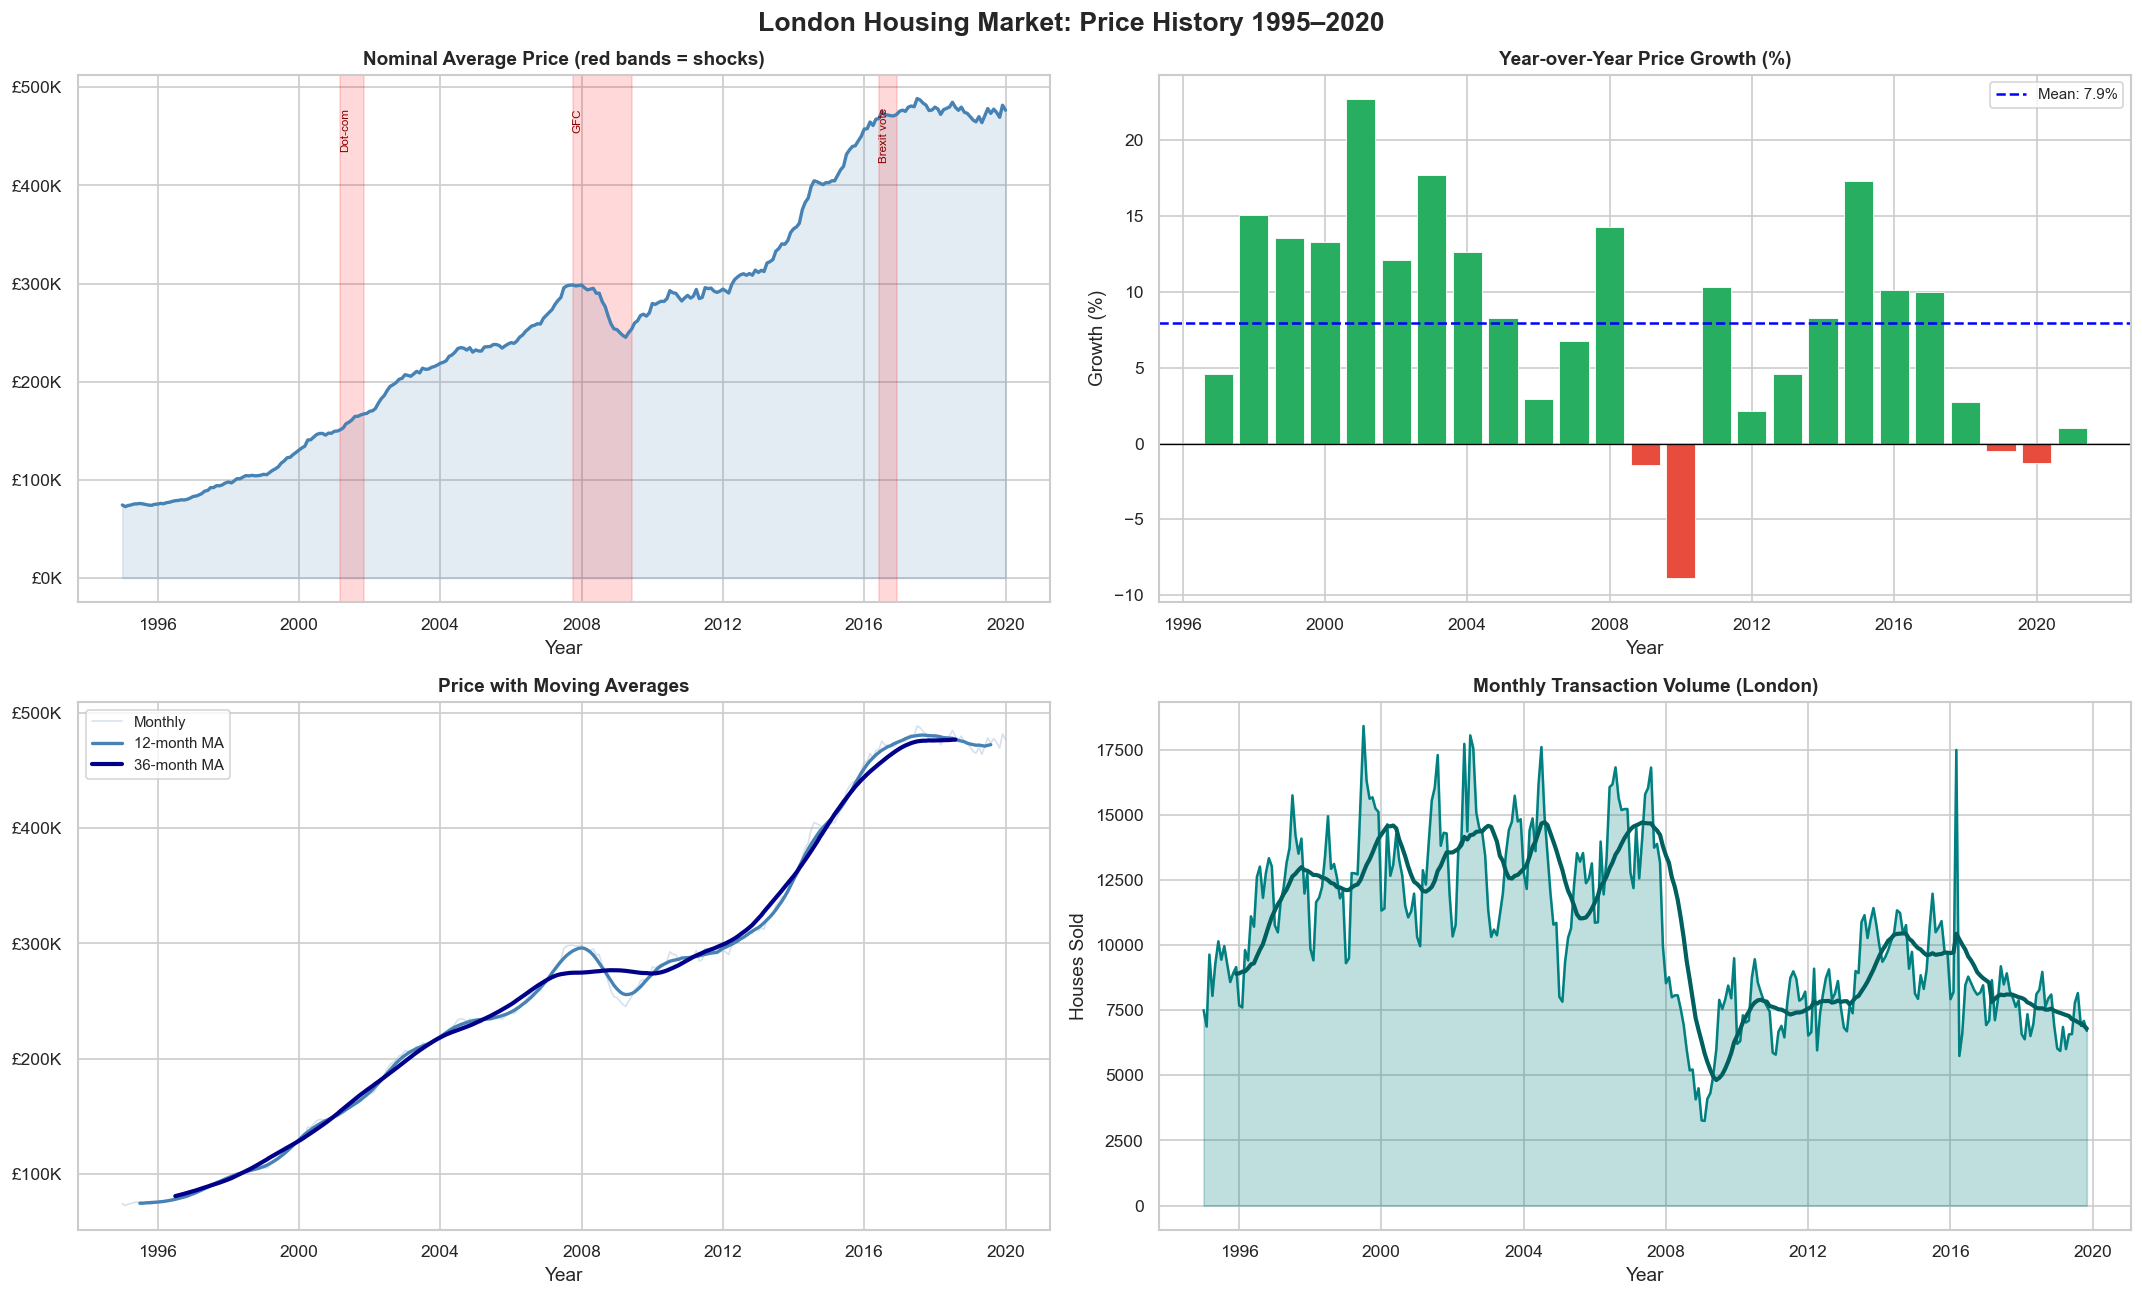

Total price appreciation 1995–2020 : 540.3%
Peak price                          : £488,527 (Jul 2017)
Best YoY growth year                : 2000 (22.8%)
Worst YoY growth year               : 2009 (-8.9%)


In [14]:
london = monthly[monthly['area'] == 'london'].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle('London Housing Market: Price History 1995–2020', fontsize=16, fontweight='bold')

# --- Nominal price with recession shading ---
ax = axes[0, 0]
ax.fill_between(london['date'], london['average_price'], alpha=0.15, color='steelblue')
ax.plot(london['date'], london['average_price'], color='steelblue', linewidth=2)
shocks = [
    ('2001-03-01', '2001-11-01', 'Dot-com'),
    ('2007-10-01', '2009-06-01', 'GFC'),
    ('2016-06-01', '2016-12-01', 'Brexit vote')
]
for start, end, lbl in shocks:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color='red')
    ax.text(pd.Timestamp(start), london['average_price'].max() * 0.98, lbl,
            fontsize=7, color='darkred', rotation=90, va='top')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('Nominal Average Price (red bands = shocks)', fontweight='bold')
ax.set_xlabel('Year')

# --- YoY growth rate ---
ax2 = axes[0, 1]
annual = london.set_index('date')['average_price'].resample('YE').mean()
yoy = annual.pct_change() * 100
bar_colors = ['#27ae60' if v >= 0 else '#e74c3c' for v in yoy.values]
ax2.bar(yoy.index, yoy.values, color=bar_colors, width=300, edgecolor='white', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline(yoy.mean(), color='blue', linestyle='--', linewidth=1.5,
            label=f'Mean: {yoy.mean():.1f}%')
ax2.set_title('Year-over-Year Price Growth (%)', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Growth (%)')
ax2.legend(fontsize=9)

# --- Rolling MA ---
ax3 = axes[1, 0]
ts_idx = london.set_index('date')['average_price']
rolling12 = ts_idx.rolling(12, center=True).mean()
rolling36 = ts_idx.rolling(36, center=True).mean()
ax3.plot(london['date'], london['average_price'], color='lightsteelblue', alpha=0.5, linewidth=1, label='Monthly')
ax3.plot(rolling12.index, rolling12.values, color='steelblue', linewidth=2, label='12-month MA')
ax3.plot(rolling36.index, rolling36.values, color='darkblue', linewidth=2.5, label='36-month MA')
ax3.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax3.set_title('Price with Moving Averages', fontweight='bold')
ax3.set_xlabel('Year')
ax3.legend(fontsize=9)

# --- Transaction volume ---
ax4 = axes[1, 1]
sold = london[['date', 'houses_sold']].dropna()
ax4.fill_between(sold['date'], sold['houses_sold'], alpha=0.25, color='teal')
ax4.plot(sold['date'], sold['houses_sold'], color='teal', linewidth=1.5)
ax4.plot(sold.set_index('date')['houses_sold'].rolling(12).mean().index,
         sold.set_index('date')['houses_sold'].rolling(12).mean().values,
         color='darkteal' if 'darkteal' in plt.colormaps() else '#005f5f',
         linewidth=2.5, label='12m MA')
ax4.set_title('Monthly Transaction Volume (London)', fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Houses Sold')

plt.tight_layout()
plt.show()

total_gain = (london['average_price'].iloc[-1] / london['average_price'].iloc[0] - 1) * 100
peak_val   = london['average_price'].max()
peak_date  = london.loc[london['average_price'].idxmax(), 'date'].strftime('%b %Y')
print(f'Total price appreciation 1995–2020 : {total_gain:.1f}%')
print(f'Peak price                          : £{peak_val:,.0f} ({peak_date})')
print(f'Best YoY growth year                : {yoy.idxmax().year} ({yoy.max():.1f}%)')
print(f'Worst YoY growth year               : {yoy.idxmin().year} ({yoy.min():.1f}%)')

## 5 — EDA: Borough-Level Price Comparison

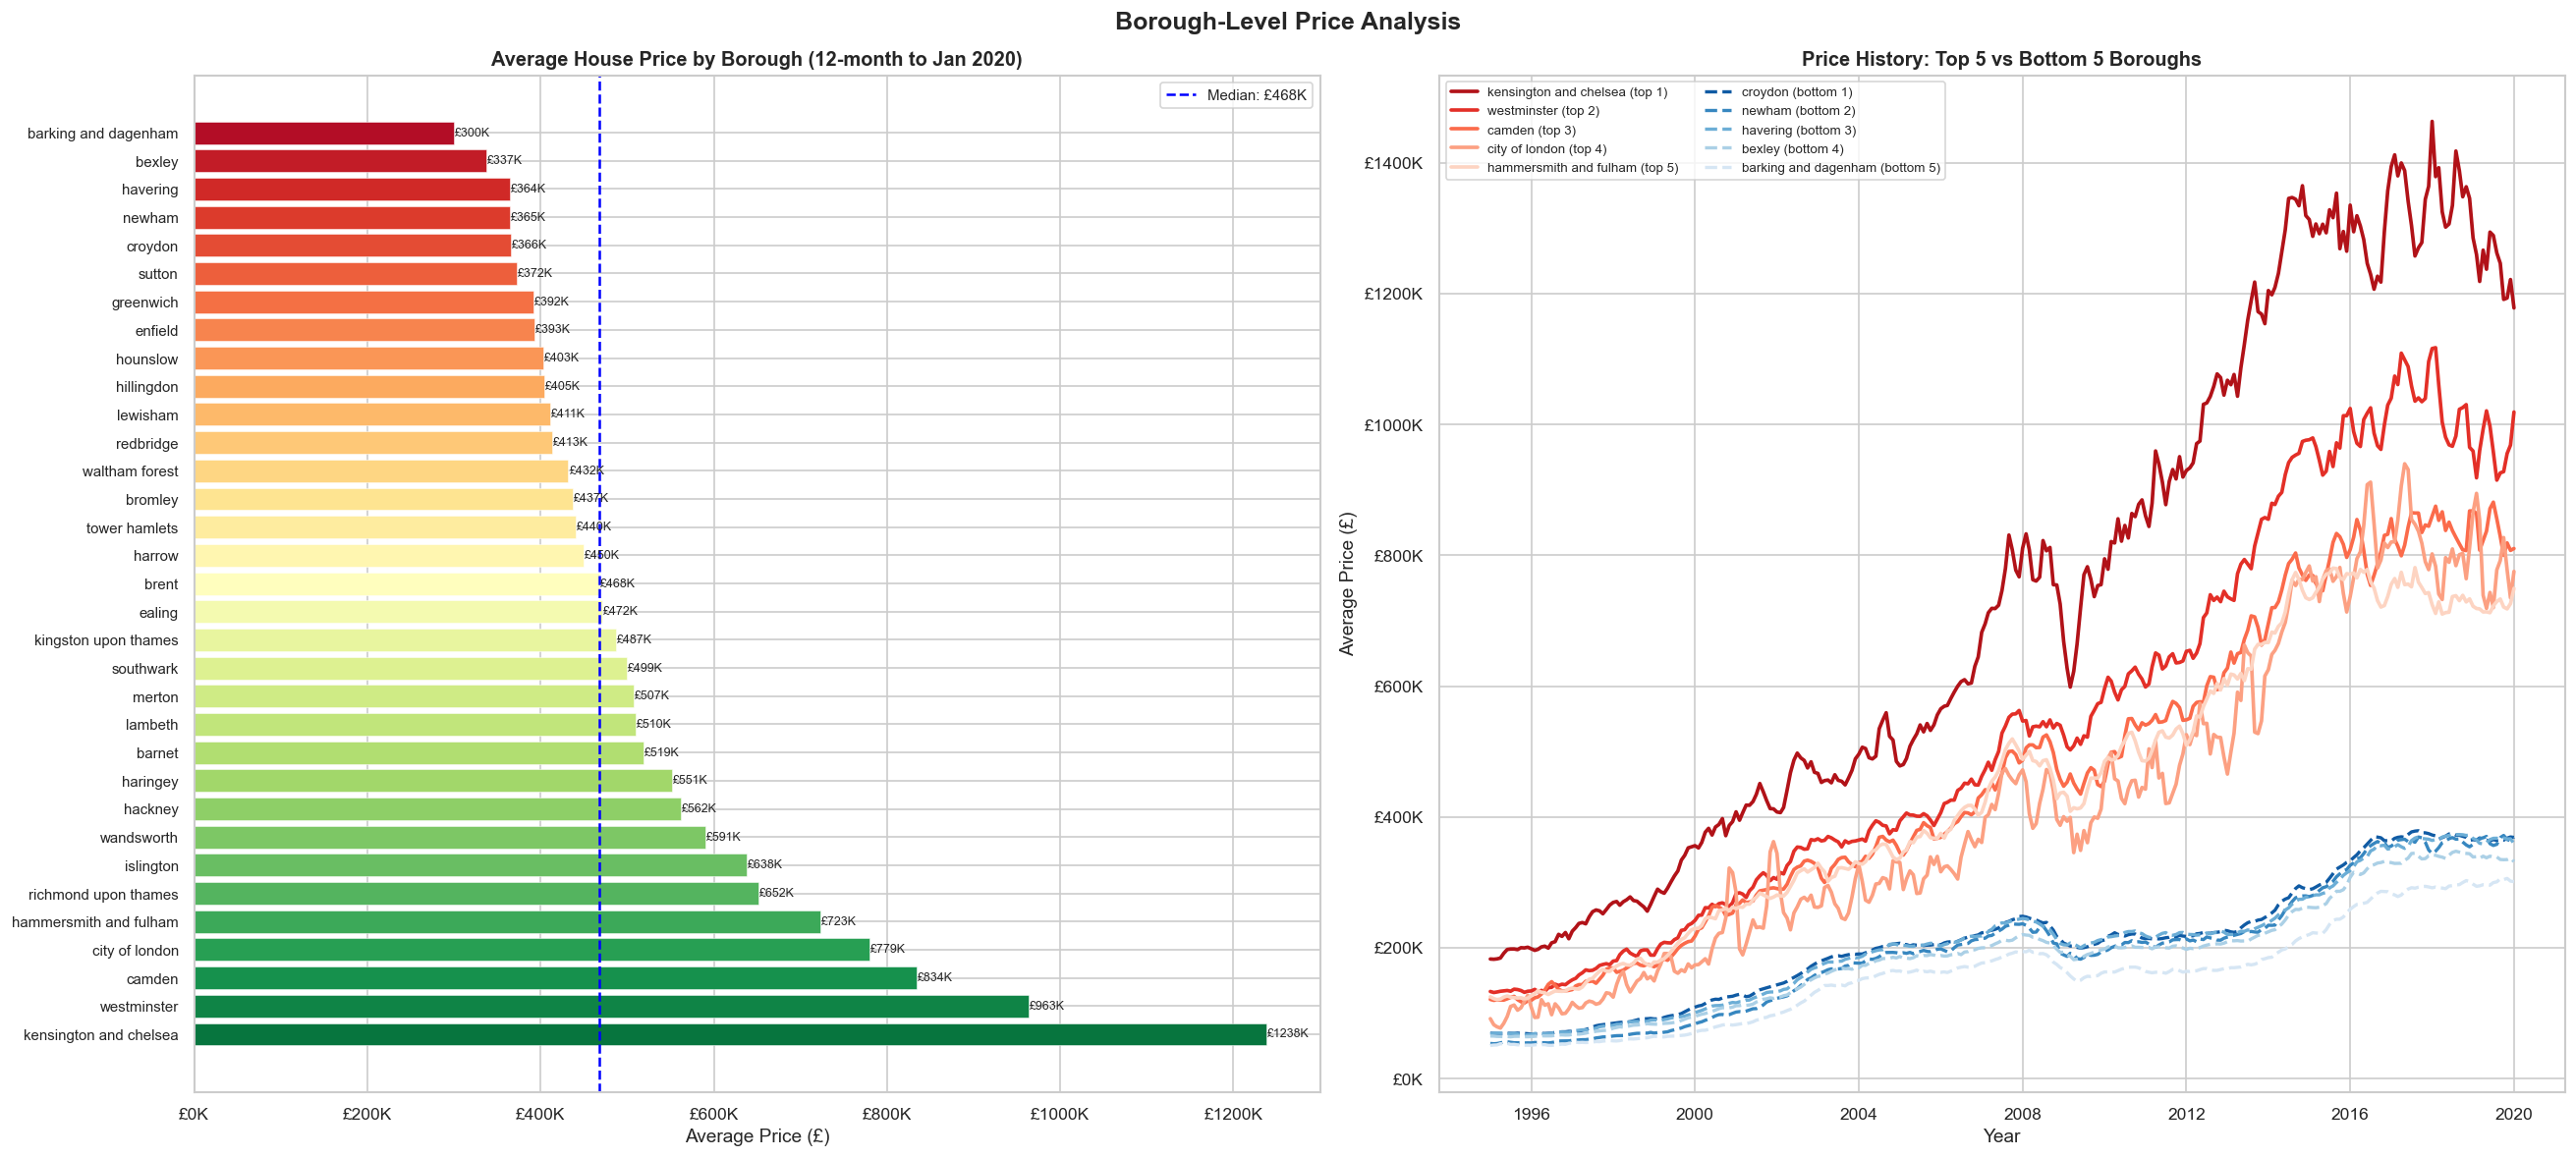

Most expensive  : kensington and chelsea  → £1,238,194
Least expensive : barking and dagenham → £299,617
Price gap (ratio): 4.1x


In [15]:
boroughs = monthly[monthly['borough_flag'] == 1].copy()

# Latest 12-month average per borough
latest_cutoff = boroughs['date'].max() - pd.DateOffset(months=11)
recent_price = (boroughs[boroughs['date'] >= latest_cutoff]
                .groupby('area')['average_price'].mean()
                .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
fig.suptitle('Borough-Level Price Analysis', fontsize=15, fontweight='bold')

# --- Ranked bar chart ---
ax1 = axes[0]
n = len(recent_price)
colors = sns.color_palette('RdYlGn_r', n)
ax1.barh(range(n), recent_price.values, color=colors, edgecolor='white', linewidth=0.3)
ax1.set_yticks(range(n))
ax1.set_yticklabels(recent_price.index, fontsize=9)
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax1.set_title('Average House Price by Borough (12-month to Jan 2020)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Average Price (£)')
ax1.axvline(recent_price.median(), color='blue', linestyle='--', linewidth=1.5,
            label=f'Median: £{recent_price.median()/1000:.0f}K')
ax1.legend(fontsize=9)
for i, v in enumerate(recent_price.values):
    ax1.text(v + 1000, i, f'£{v/1000:.0f}K', va='center', fontsize=7.5)

# --- Top 5 vs bottom 5 price history ---
ax2 = axes[1]
top5 = recent_price.head(5).index.tolist()
bot5 = recent_price.tail(5).index.tolist()

palette_top = sns.color_palette('Reds_r', 5)
palette_bot = sns.color_palette('Blues_r', 5)

for i, area in enumerate(top5):
    d = boroughs[boroughs['area'] == area].set_index('date')['average_price']
    ax2.plot(d.index, d.values, color=palette_top[i], linewidth=2.2,
             label=f'{area} (top {i+1})')

for i, area in enumerate(bot5):
    d = boroughs[boroughs['area'] == area].set_index('date')['average_price']
    ax2.plot(d.index, d.values, color=palette_bot[i], linewidth=2, linestyle='--',
             label=f'{area} (bottom {i+1})')

ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax2.set_title('Price History: Top 5 vs Bottom 5 Boroughs', fontweight='bold', fontsize=12)
ax2.set_xlabel('Year')
ax2.set_ylabel('Average Price (£)')
ax2.legend(fontsize=8, ncol=2, loc='upper left')

plt.tight_layout()
plt.show()

gap = recent_price.iloc[0] / recent_price.iloc[-1]
print(f'Most expensive  : {recent_price.index[0]}  → £{recent_price.iloc[0]:,.0f}')
print(f'Least expensive : {recent_price.index[-1]} → £{recent_price.iloc[-1]:,.0f}')
print(f'Price gap (ratio): {gap:.1f}x')

## 6 — EDA: Price Distributions, Seasonality & Decade Shifts

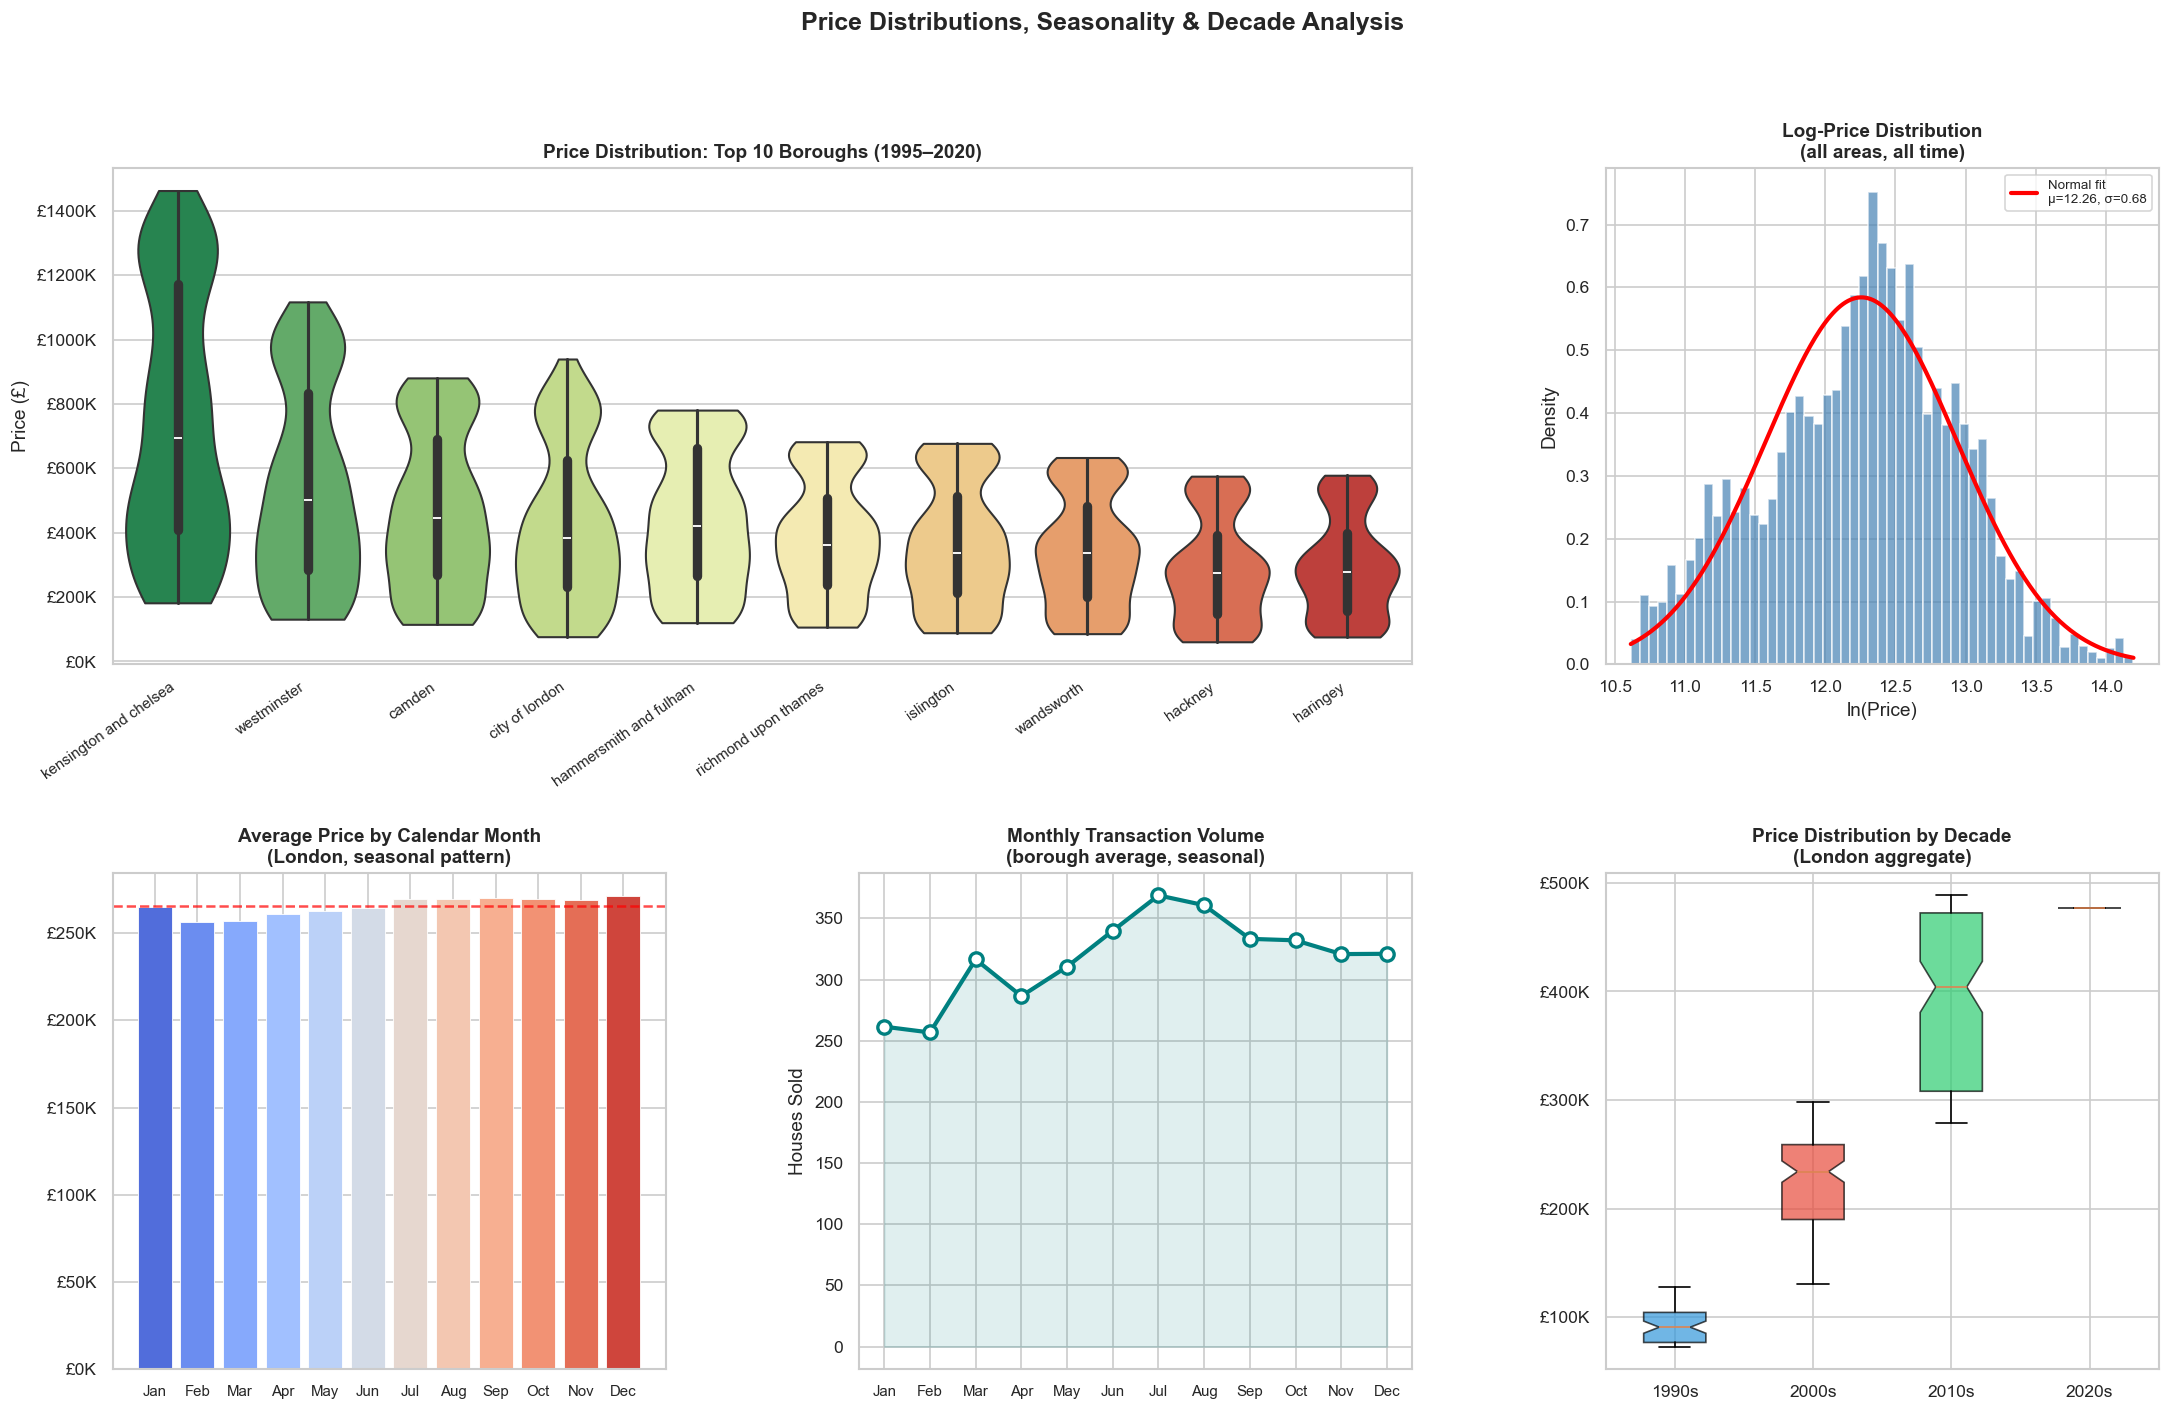

In [16]:
fig = plt.figure(figsize=(22, 13))
gs  = gridspec.GridSpec(2, 3, hspace=0.42, wspace=0.35)

# --- Violin plot: top 10 boroughs ---
ax1 = fig.add_subplot(gs[0, :2])
top10 = recent_price.head(10).index.tolist()
plot_data = boroughs[boroughs['area'].isin(top10)][['area', 'average_price']].dropna()
sns.violinplot(data=plot_data, x='area', y='average_price', order=top10,
               palette='RdYlGn_r', ax=ax1, inner='box', cut=0)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax1.set_title('Price Distribution: Top 10 Boroughs (1995–2020)', fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Price (£)')

# --- Log-normal distribution fit ---
ax2 = fig.add_subplot(gs[0, 2])
all_prices = monthly['average_price'].dropna()
log_p = np.log(all_prices)
ax2.hist(log_p, bins=55, color='steelblue', alpha=0.7, edgecolor='white', density=True)
mu, sigma = log_p.mean(), log_p.std()
x = np.linspace(log_p.min(), log_p.max(), 200)
ax2.plot(x, stats.norm.pdf(x, mu, sigma), color='red', linewidth=2.5, label=f'Normal fit\nμ={mu:.2f}, σ={sigma:.2f}')
ax2.set_title('Log-Price Distribution\n(all areas, all time)', fontweight='bold')
ax2.set_xlabel('ln(Price)')
ax2.set_ylabel('Density')
ax2.legend(fontsize=8)

# --- Monthly seasonality in prices ---
ax3 = fig.add_subplot(gs[1, 0])
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg = london.groupby('month')['average_price'].mean()
bars = ax3.bar(range(1, 13), monthly_avg.values,
               color=sns.color_palette('coolwarm', 12), edgecolor='white', linewidth=0.5)
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(month_names, fontsize=9)
ax3.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax3.set_title('Average Price by Calendar Month\n(London, seasonal pattern)', fontweight='bold')
ax3.axhline(monthly_avg.mean(), color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# --- Transaction seasonality ---
ax4 = fig.add_subplot(gs[1, 1])
boroughs['month_'] = boroughs['date'].dt.month
sales_season = boroughs.groupby('month_')['houses_sold'].mean()
ax4.plot(range(1, 13), sales_season.values, marker='o', color='teal',
         linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
ax4.fill_between(range(1, 13), sales_season.values, alpha=0.12, color='teal')
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(month_names, fontsize=9)
ax4.set_title('Monthly Transaction Volume\n(borough average, seasonal)', fontweight='bold')
ax4.set_ylabel('Houses Sold')

# --- Decade-by-decade price shift ---
ax5 = fig.add_subplot(gs[1, 2])
london_d = monthly[monthly['area'] == 'london'].copy()
london_d['decade'] = (london_d['date'].dt.year // 10 * 10).astype(str) + 's'
decade_order = ['1990s', '2000s', '2010s', '2020s']
decade_data  = [london_d[london_d['decade'] == d]['average_price'].dropna()
                for d in decade_order if d in london_d['decade'].unique()]
decade_labels = [d for d in decade_order if d in london_d['decade'].unique()]
bp = ax5.boxplot(decade_data, labels=decade_labels, patch_artist=True, notch=True)
dec_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
for patch, col in zip(bp['boxes'], dec_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
ax5.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax5.set_title('Price Distribution by Decade\n(London aggregate)', fontweight='bold')

plt.suptitle('Price Distributions, Seasonality & Decade Analysis', fontsize=15, fontweight='bold')
plt.show()

## 7 — EDA: Crime Analysis

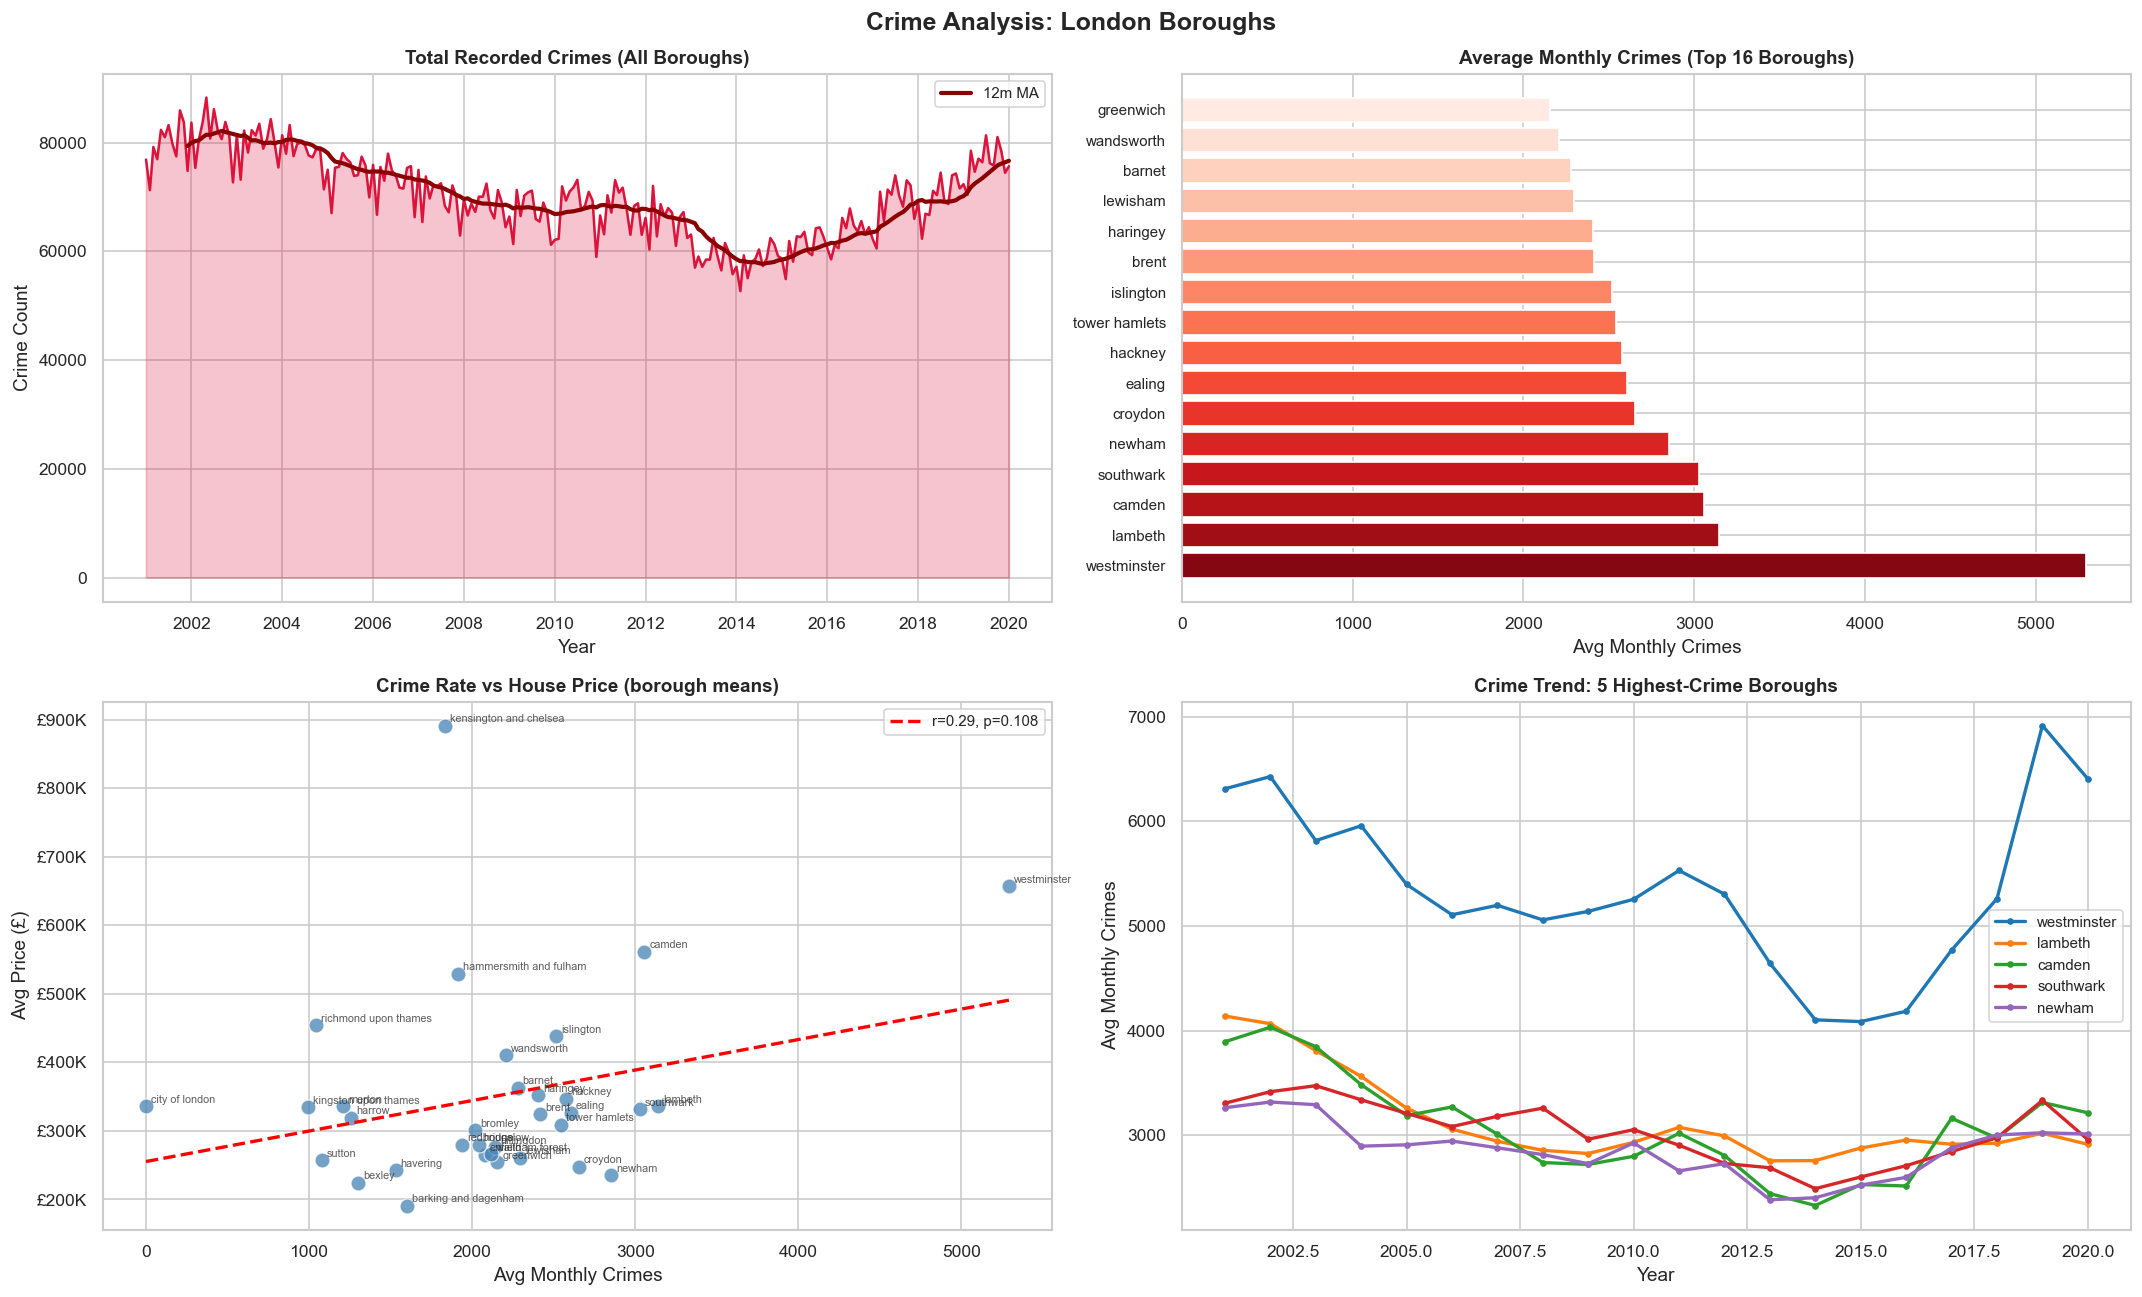

Pearson r (crime vs price, borough level): 0.285  [p = 0.1075]
Interpretation: positive — higher-crime areas tend to have higher prices (central density effect)


In [17]:
crime_df = (monthly[monthly['borough_flag'] == 1]
            [['date', 'area', 'average_price', 'no_of_crimes']]
            .dropna())

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle('Crime Analysis: London Boroughs', fontsize=15, fontweight='bold')

# --- Total crime over time ---
ax1 = axes[0, 0]
crime_ts = crime_df.groupby('date')['no_of_crimes'].sum()
ax1.fill_between(crime_ts.index, crime_ts.values, alpha=0.25, color='crimson')
ax1.plot(crime_ts.index, crime_ts.values, color='crimson', linewidth=1.5)
ax1.plot(crime_ts.rolling(12).mean().index, crime_ts.rolling(12).mean().values,
         color='darkred', linewidth=2.5, label='12m MA')
ax1.set_title('Total Recorded Crimes (All Boroughs)', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Crime Count')
ax1.legend(fontsize=9)

# --- Average crime by borough ---
ax2 = axes[0, 1]
crime_boro = crime_df.groupby('area')['no_of_crimes'].mean().sort_values(ascending=False).head(16)
ax2.barh(range(len(crime_boro)), crime_boro.values,
         color=sns.color_palette('Reds_r', len(crime_boro)))
ax2.set_yticks(range(len(crime_boro)))
ax2.set_yticklabels(crime_boro.index, fontsize=9)
ax2.set_title('Average Monthly Crimes (Top 16 Boroughs)', fontweight='bold')
ax2.set_xlabel('Avg Monthly Crimes')

# --- Crime vs Price scatter with regression ---
ax3 = axes[1, 0]
crime_price = crime_df.groupby('area').agg({'no_of_crimes': 'mean', 'average_price': 'mean'}).dropna()
ax3.scatter(crime_price['no_of_crimes'], crime_price['average_price'],
            s=80, alpha=0.75, color='steelblue', edgecolors='white', linewidth=0.7)
for area, row in crime_price.iterrows():
    ax3.annotate(area, (row['no_of_crimes'], row['average_price']),
                 fontsize=6.5, alpha=0.75, xytext=(3, 2), textcoords='offset points')
r, p = stats.pearsonr(crime_price['no_of_crimes'], crime_price['average_price'])
z = np.polyfit(crime_price['no_of_crimes'], crime_price['average_price'], 1)
xfit = np.linspace(crime_price['no_of_crimes'].min(), crime_price['no_of_crimes'].max(), 100)
ax3.plot(xfit, np.poly1d(z)(xfit), color='red', linewidth=2, linestyle='--',
         label=f'r={r:.2f}, p={p:.3f}')
ax3.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax3.set_title('Crime Rate vs House Price (borough means)', fontweight='bold')
ax3.set_xlabel('Avg Monthly Crimes')
ax3.set_ylabel('Avg Price (£)')
ax3.legend(fontsize=9)

# --- Crime trend top-5 high crime boroughs ---
ax4 = axes[1, 1]
top5_crime = crime_df.groupby('area')['no_of_crimes'].mean().nlargest(5).index
crime_df['year_'] = crime_df['date'].dt.year
crime_pivot = crime_df.groupby(['year_', 'area'])['no_of_crimes'].mean().unstack()
palette = sns.color_palette('tab10', 5)
for i, area in enumerate(top5_crime):
    if area in crime_pivot.columns:
        ax4.plot(crime_pivot.index, crime_pivot[area], marker='.', linewidth=2,
                 color=palette[i], label=area)
ax4.set_title('Crime Trend: 5 Highest-Crime Boroughs', fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Avg Monthly Crimes')
ax4.legend(fontsize=9)

plt.tight_layout()
plt.show()
print(f'Pearson r (crime vs price, borough level): {r:.3f}  [p = {p:.4f}]')
interp = 'positive — higher-crime areas tend to have higher prices (central density effect)' if r > 0 else 'negative — higher-crime areas tend to be cheaper'
print(f'Interpretation: {interp}')

## 8 — EDA: Salary Dynamics (Yearly Dataset)

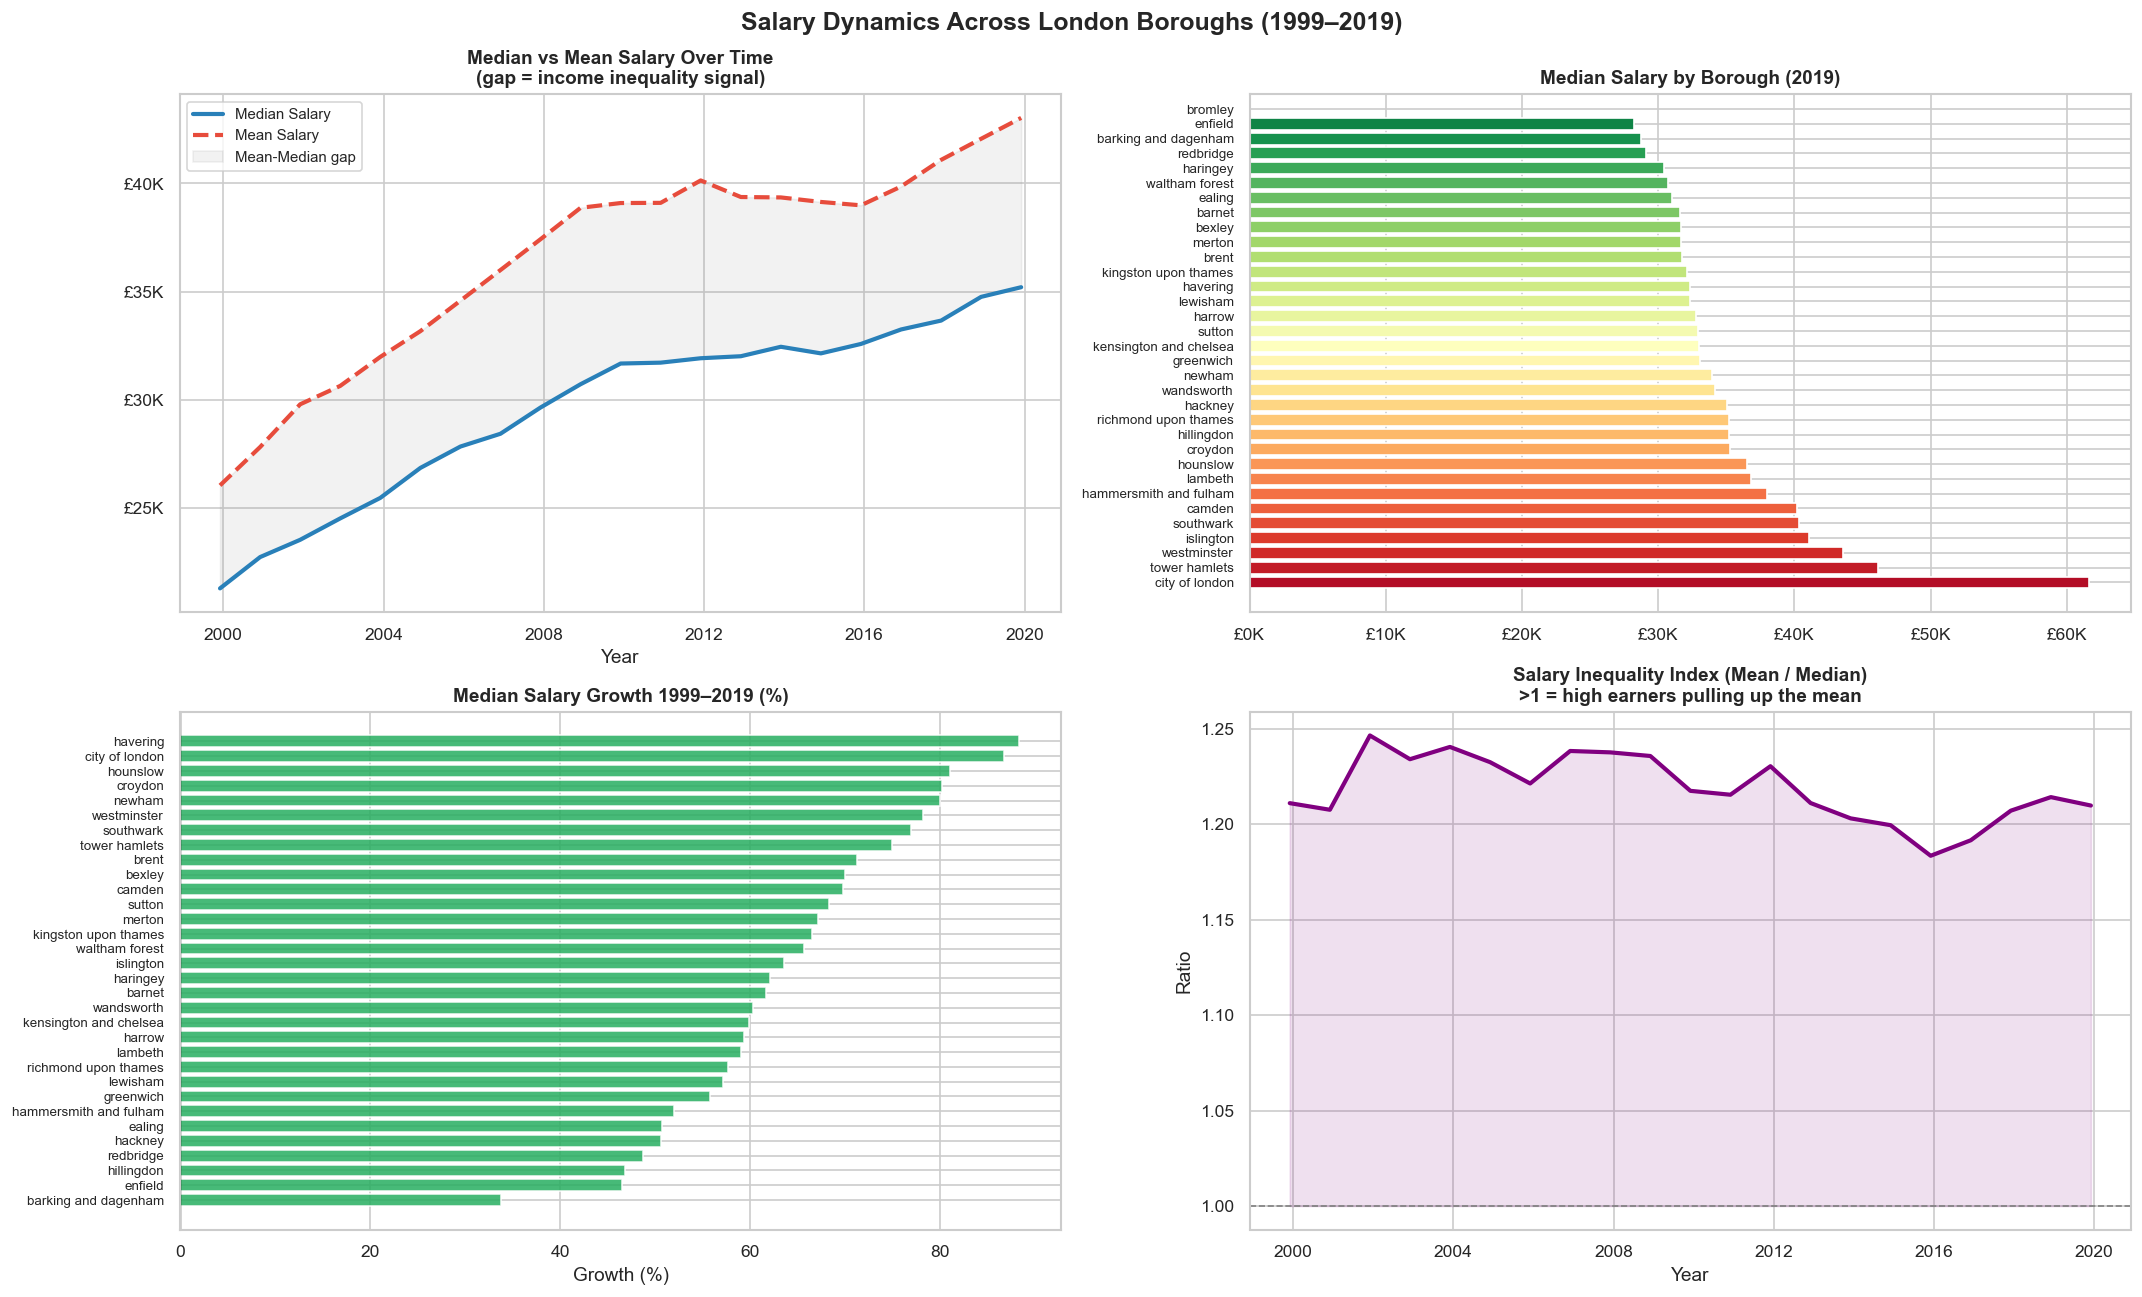

In [18]:
by_yr = yearly[yearly['borough_flag'] == 1].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle('Salary Dynamics Across London Boroughs (1999–2019)', fontsize=15, fontweight='bold')

# --- Median vs mean salary over time ---
ax1 = axes[0, 0]
sal_ts = by_yr.groupby('date')[['median_salary', 'mean_salary']].mean()
ax1.plot(sal_ts.index, sal_ts['median_salary'], color='#2980b9', linewidth=2.5, label='Median Salary')
ax1.plot(sal_ts.index, sal_ts['mean_salary'], color='#e74c3c', linewidth=2.5, linestyle='--', label='Mean Salary')
ax1.fill_between(sal_ts.index, sal_ts['median_salary'], sal_ts['mean_salary'],
                 alpha=0.1, color='gray', label='Mean-Median gap')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax1.set_title('Median vs Mean Salary Over Time\n(gap = income inequality signal)', fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xlabel('Year')

# --- Salary by borough: latest year ---
ax2 = axes[0, 1]
yr_max = by_yr['year'].max()
latest_sal = (by_yr[by_yr['year'] == yr_max]
              .groupby('area')['median_salary'].mean()
              .sort_values(ascending=False))
ax2.barh(range(len(latest_sal)), latest_sal.values,
         color=sns.color_palette('RdYlGn', len(latest_sal)))
ax2.set_yticks(range(len(latest_sal)))
ax2.set_yticklabels(latest_sal.index, fontsize=8)
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax2.set_title(f'Median Salary by Borough ({yr_max})', fontweight='bold')

# --- Salary growth: first vs last year ---
ax3 = axes[1, 0]
yr_min = by_yr['year'].min()
first_sal = by_yr[by_yr['year'] == yr_min].groupby('area')['median_salary'].mean()
last_sal  = by_yr[by_yr['year'] == yr_max].groupby('area')['median_salary'].mean()
sal_growth = ((last_sal - first_sal) / first_sal * 100).dropna().sort_values()
cg = ['#27ae60' if v >= 0 else '#e74c3c' for v in sal_growth.values]
ax3.barh(range(len(sal_growth)), sal_growth.values, color=cg, alpha=0.85)
ax3.set_yticks(range(len(sal_growth)))
ax3.set_yticklabels(sal_growth.index, fontsize=8)
ax3.axvline(0, color='black', linewidth=0.8)
ax3.set_title(f'Median Salary Growth {yr_min}–{yr_max} (%)', fontweight='bold')
ax3.set_xlabel('Growth (%)')

# --- Salary inequality index ---
ax4 = axes[1, 1]
by_yr['salary_skew'] = by_yr['mean_salary'] / by_yr['median_salary']
skew_ts = by_yr.groupby('date')['salary_skew'].mean()
ax4.plot(skew_ts.index, skew_ts.values, color='purple', linewidth=2.5)
ax4.fill_between(skew_ts.index, skew_ts.values, 1, alpha=0.12, color='purple')
ax4.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax4.set_title('Salary Inequality Index (Mean / Median)\n>1 = high earners pulling up the mean', fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Ratio')

plt.tight_layout()
plt.show()

## 9 — EDA: Population, Jobs & Housing Stock

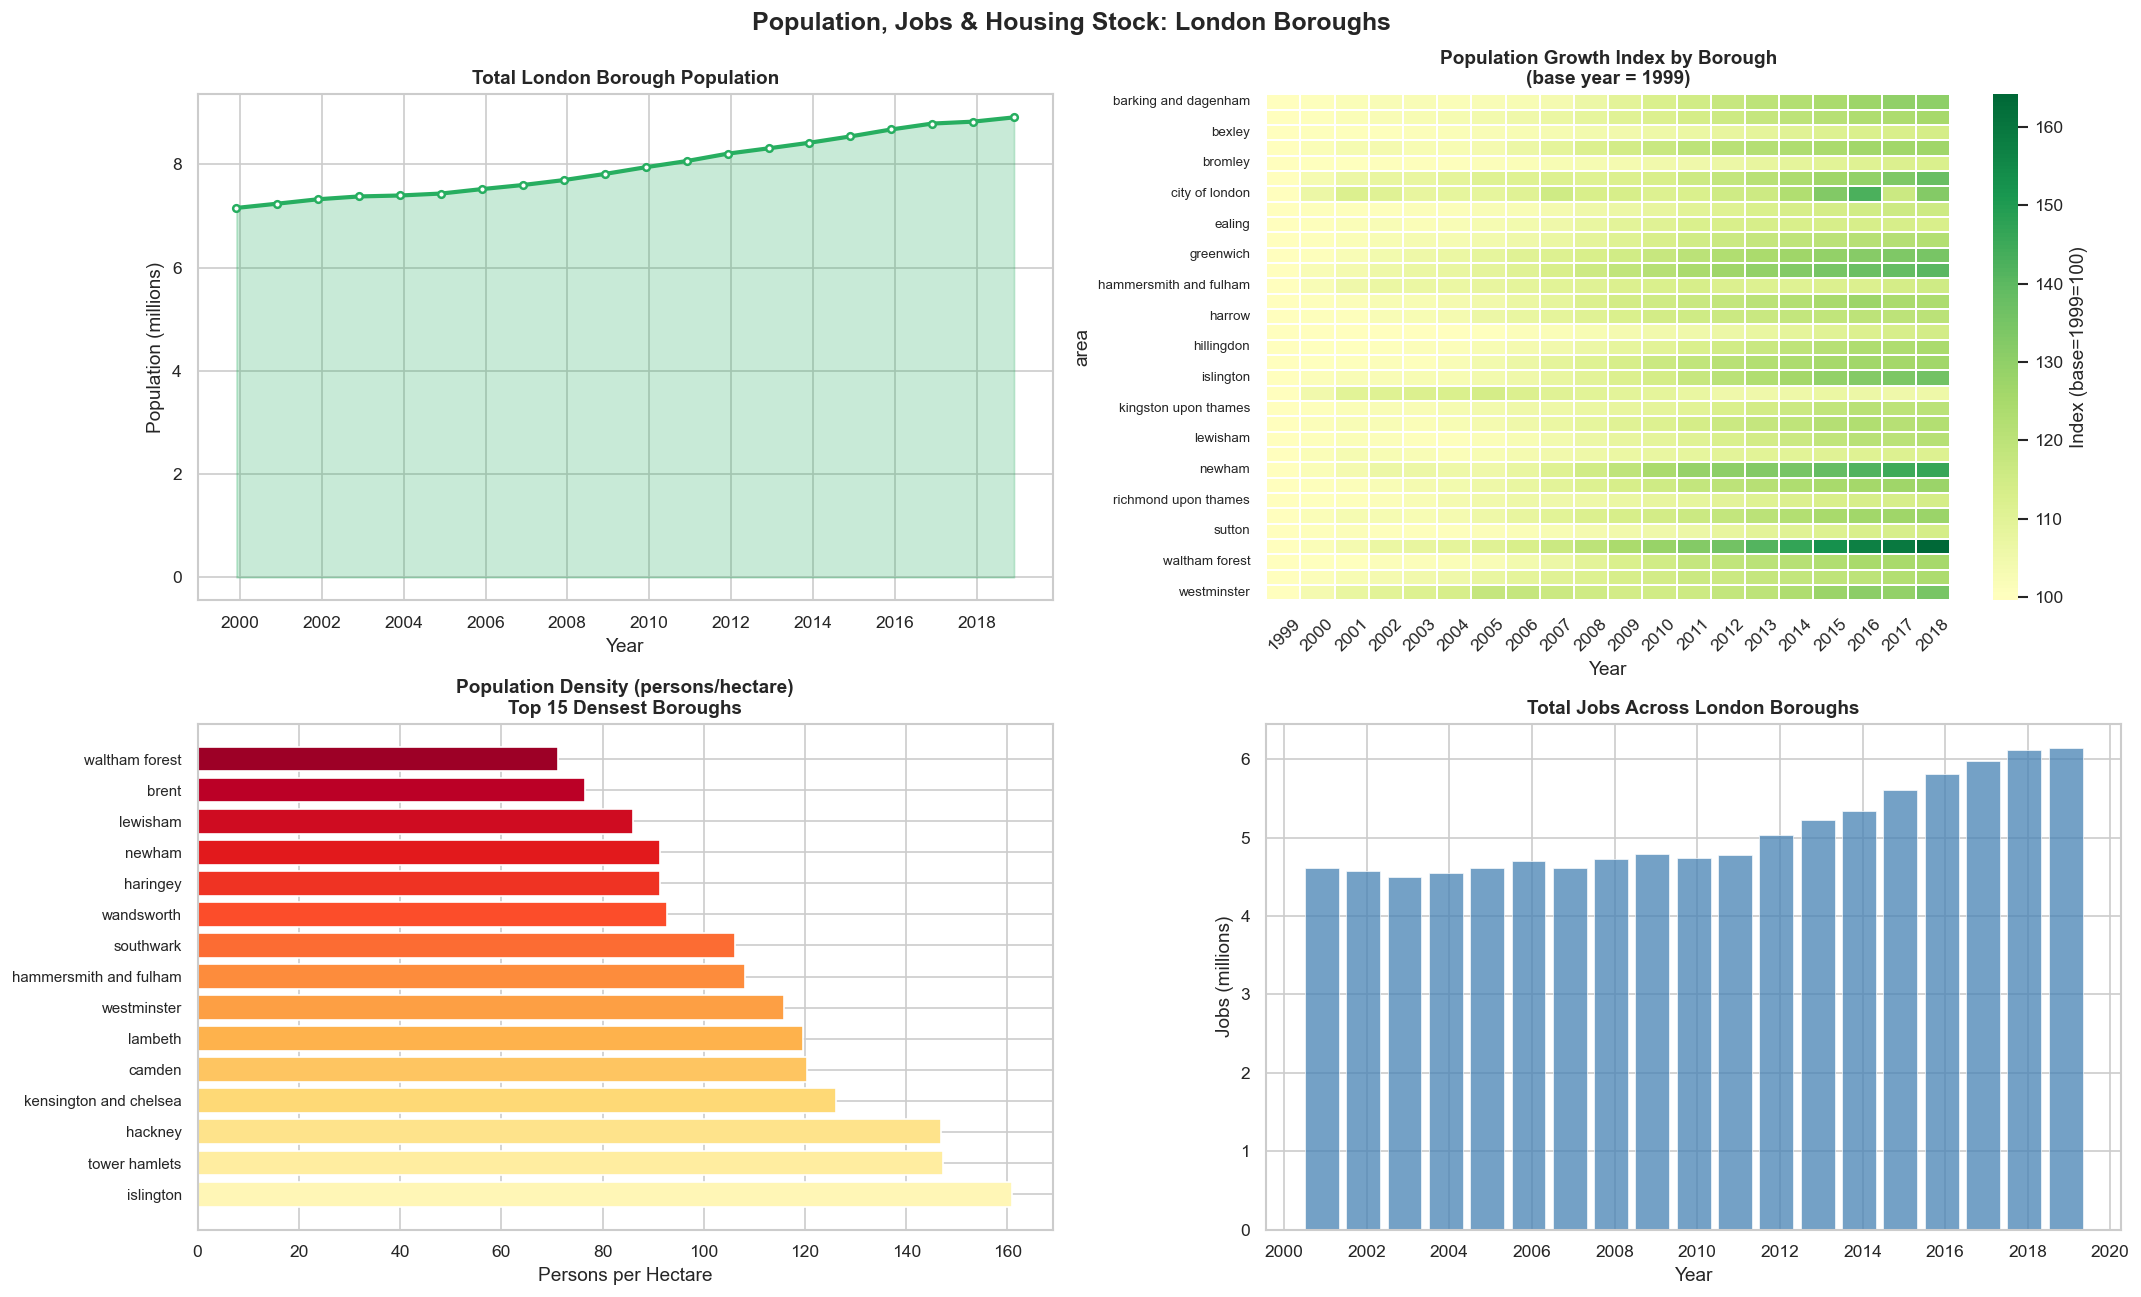

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle('Population, Jobs & Housing Stock: London Boroughs', fontsize=15, fontweight='bold')

# --- Total population over time ---
ax1 = axes[0, 0]
pop_ts = by_yr.dropna(subset=['population_size']).groupby('date')['population_size'].sum()
ax1.fill_between(pop_ts.index, pop_ts.values / 1e6, alpha=0.25, color='#27ae60')
ax1.plot(pop_ts.index, pop_ts.values / 1e6, color='#27ae60', linewidth=2.5,
         marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1.5)
ax1.set_title('Total London Borough Population', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Population (millions)')

# --- Population heatmap by borough ---
ax2 = axes[0, 1]
pop_pivot = (by_yr.dropna(subset=['population_size'])
             .pivot_table(index='area', columns='year', values='population_size'))
base_year = pop_pivot.columns[0]
pop_norm = pop_pivot.div(pop_pivot[base_year], axis=0) * 100
sns.heatmap(pop_norm, ax=ax2, cmap='RdYlGn', center=100,
            linewidths=0.2, linecolor='white', annot=False,
            cbar_kws={'label': f'Index (base={base_year}=100)'})
ax2.set_title(f'Population Growth Index by Borough\n(base year = {base_year})', fontweight='bold')
ax2.set_xlabel('Year')
ax2.tick_params(axis='y', labelsize=8)
ax2.tick_params(axis='x', rotation=45)

# --- Population density ---
ax3 = axes[1, 0]
dens = by_yr.dropna(subset=['population_size', 'area_size']).copy()
dens['density'] = dens['population_size'] / dens['area_size']
dens_latest = (dens[dens['year'] == dens['year'].max()]
               .groupby('area')['density'].mean()
               .sort_values(ascending=False)
               .head(15))
ax3.barh(range(len(dens_latest)), dens_latest.values,
         color=sns.color_palette('YlOrRd', len(dens_latest)))
ax3.set_yticks(range(len(dens_latest)))
ax3.set_yticklabels(dens_latest.index, fontsize=9)
ax3.set_title('Population Density (persons/hectare)\nTop 15 Densest Boroughs', fontweight='bold')
ax3.set_xlabel('Persons per Hectare')

# --- Jobs over time ---
ax4 = axes[1, 1]
jobs_ts = by_yr.dropna(subset=['number_of_jobs']).groupby('date')['number_of_jobs'].sum()
ax4.bar(jobs_ts.index, jobs_ts.values / 1e6, color='steelblue', alpha=0.75, width=300,
        edgecolor='white', linewidth=0.5)
ax4.set_title('Total Jobs Across London Boroughs', fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Jobs (millions)')

plt.tight_layout()
plt.show()

## 10 — EDA: Wellbeing & Environmental Indicators

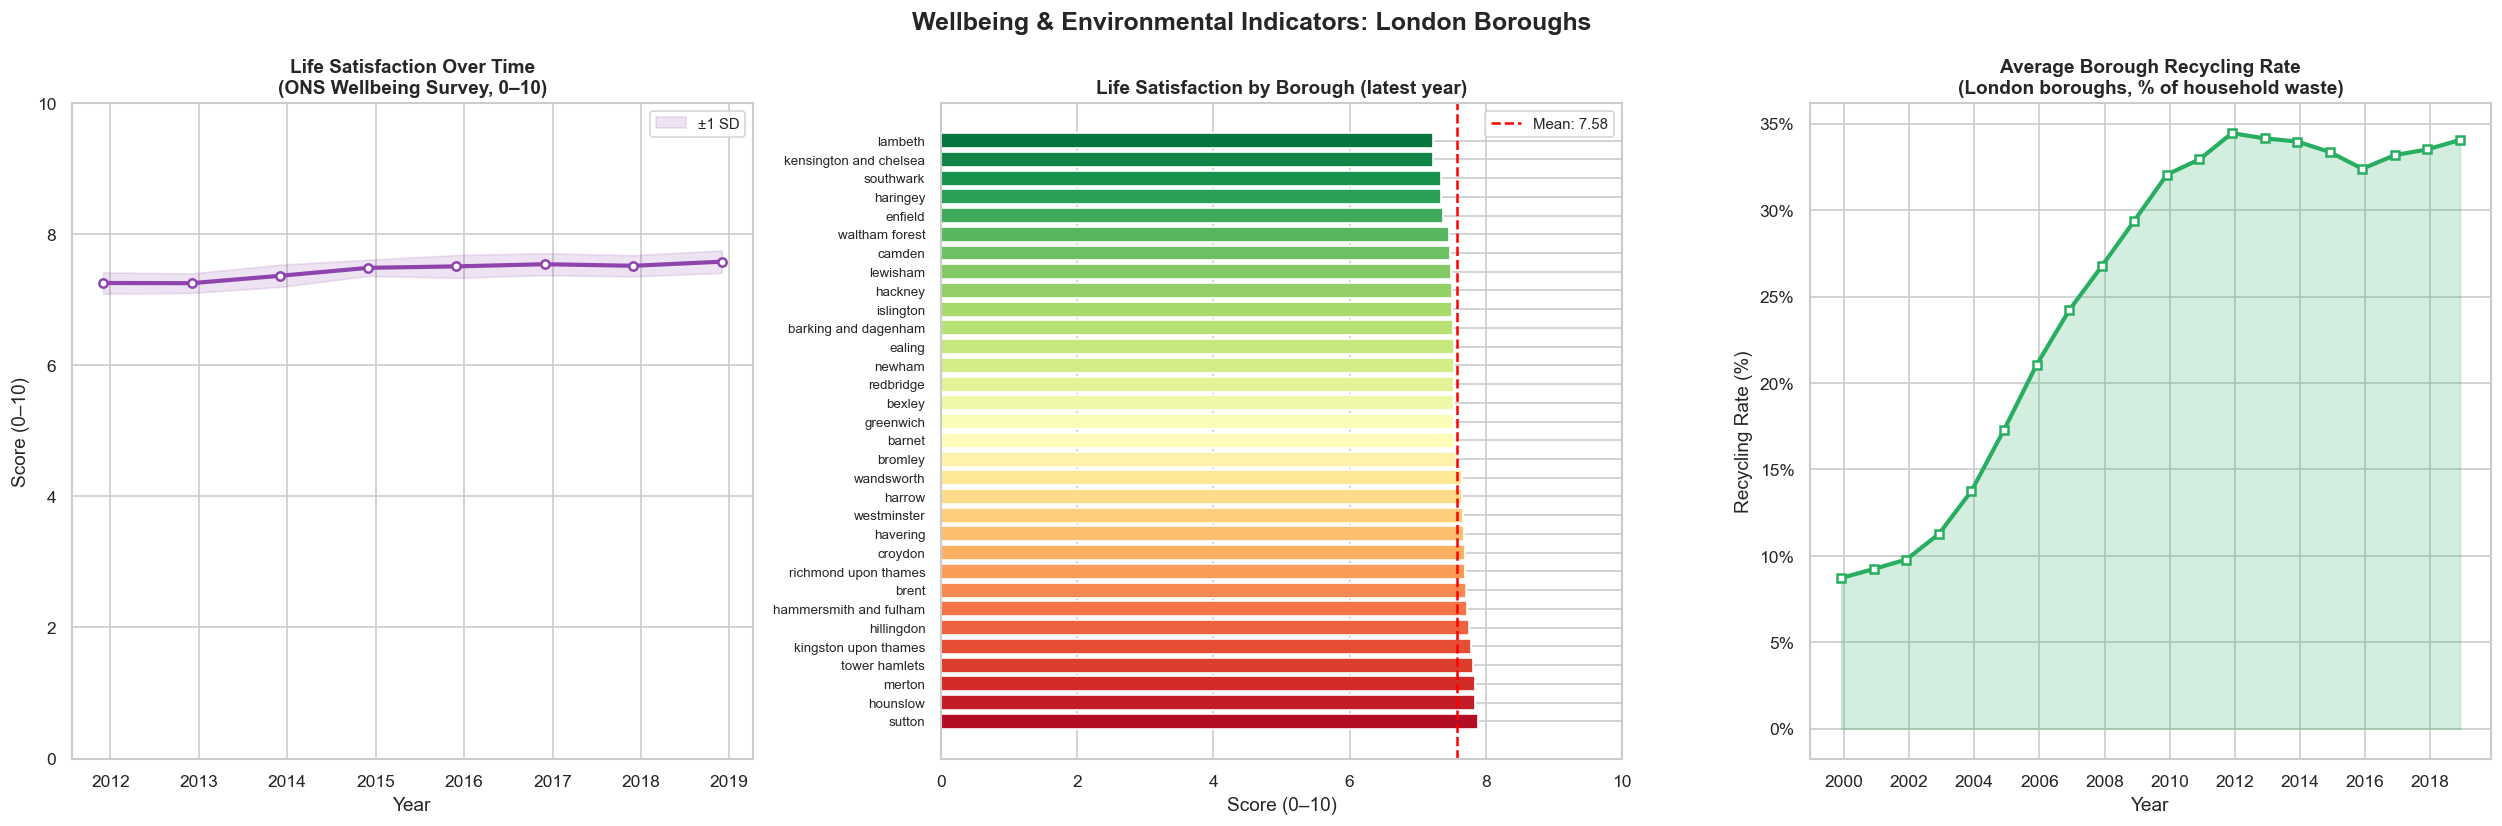

In [20]:
wb = by_yr.dropna(subset=['life_satisfaction'])

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('Wellbeing & Environmental Indicators: London Boroughs', fontsize=15, fontweight='bold')

# --- Life satisfaction over time ---
ax1 = axes[0]
ls_ts  = wb.groupby('date')['life_satisfaction'].mean()
ls_std = wb.groupby('date')['life_satisfaction'].std()
ax1.plot(ls_ts.index, ls_ts.values, color='#8e44ad', linewidth=2.5,
         marker='o', markersize=5, markerfacecolor='white', markeredgewidth=1.5)
ax1.fill_between(ls_ts.index, ls_ts - ls_std, ls_ts + ls_std,
                 alpha=0.15, color='#8e44ad', label='±1 SD')
ax1.set_ylim(0, 10)
ax1.set_title('Life Satisfaction Over Time\n(ONS Wellbeing Survey, 0–10)', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Score (0–10)')
ax1.legend(fontsize=9)

# --- Life satisfaction by borough ---
ax2 = axes[1]
ls_latest = (wb[wb['year'] == wb['year'].max()]
             .groupby('area')['life_satisfaction'].mean()
             .sort_values(ascending=False))
colors_ls = sns.color_palette('RdYlGn', len(ls_latest))
ax2.barh(range(len(ls_latest)), ls_latest.values, color=colors_ls)
ax2.set_yticks(range(len(ls_latest)))
ax2.set_yticklabels(ls_latest.index, fontsize=8)
ax2.set_xlim(0, 10)
ax2.axvline(ls_latest.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean: {ls_latest.mean():.2f}')
ax2.set_title('Life Satisfaction by Borough (latest year)', fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlabel('Score (0–10)')

# --- Recycling trend ---
ax3 = axes[2]
rec_ts = by_yr.dropna(subset=['recycling_pct']).groupby('date')['recycling_pct'].mean()
ax3.fill_between(rec_ts.index, rec_ts.values, alpha=0.2, color='#27ae60')
ax3.plot(rec_ts.index, rec_ts.values, color='#27ae60', linewidth=2.5,
         marker='s', markersize=5, markerfacecolor='white', markeredgewidth=1.5)
ax3.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax3.set_title('Average Borough Recycling Rate\n(London boroughs, % of household waste)', fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Recycling Rate (%)')

plt.tight_layout()
plt.show()

## 11 — Affordability Analysis: Price-to-Income Ratio

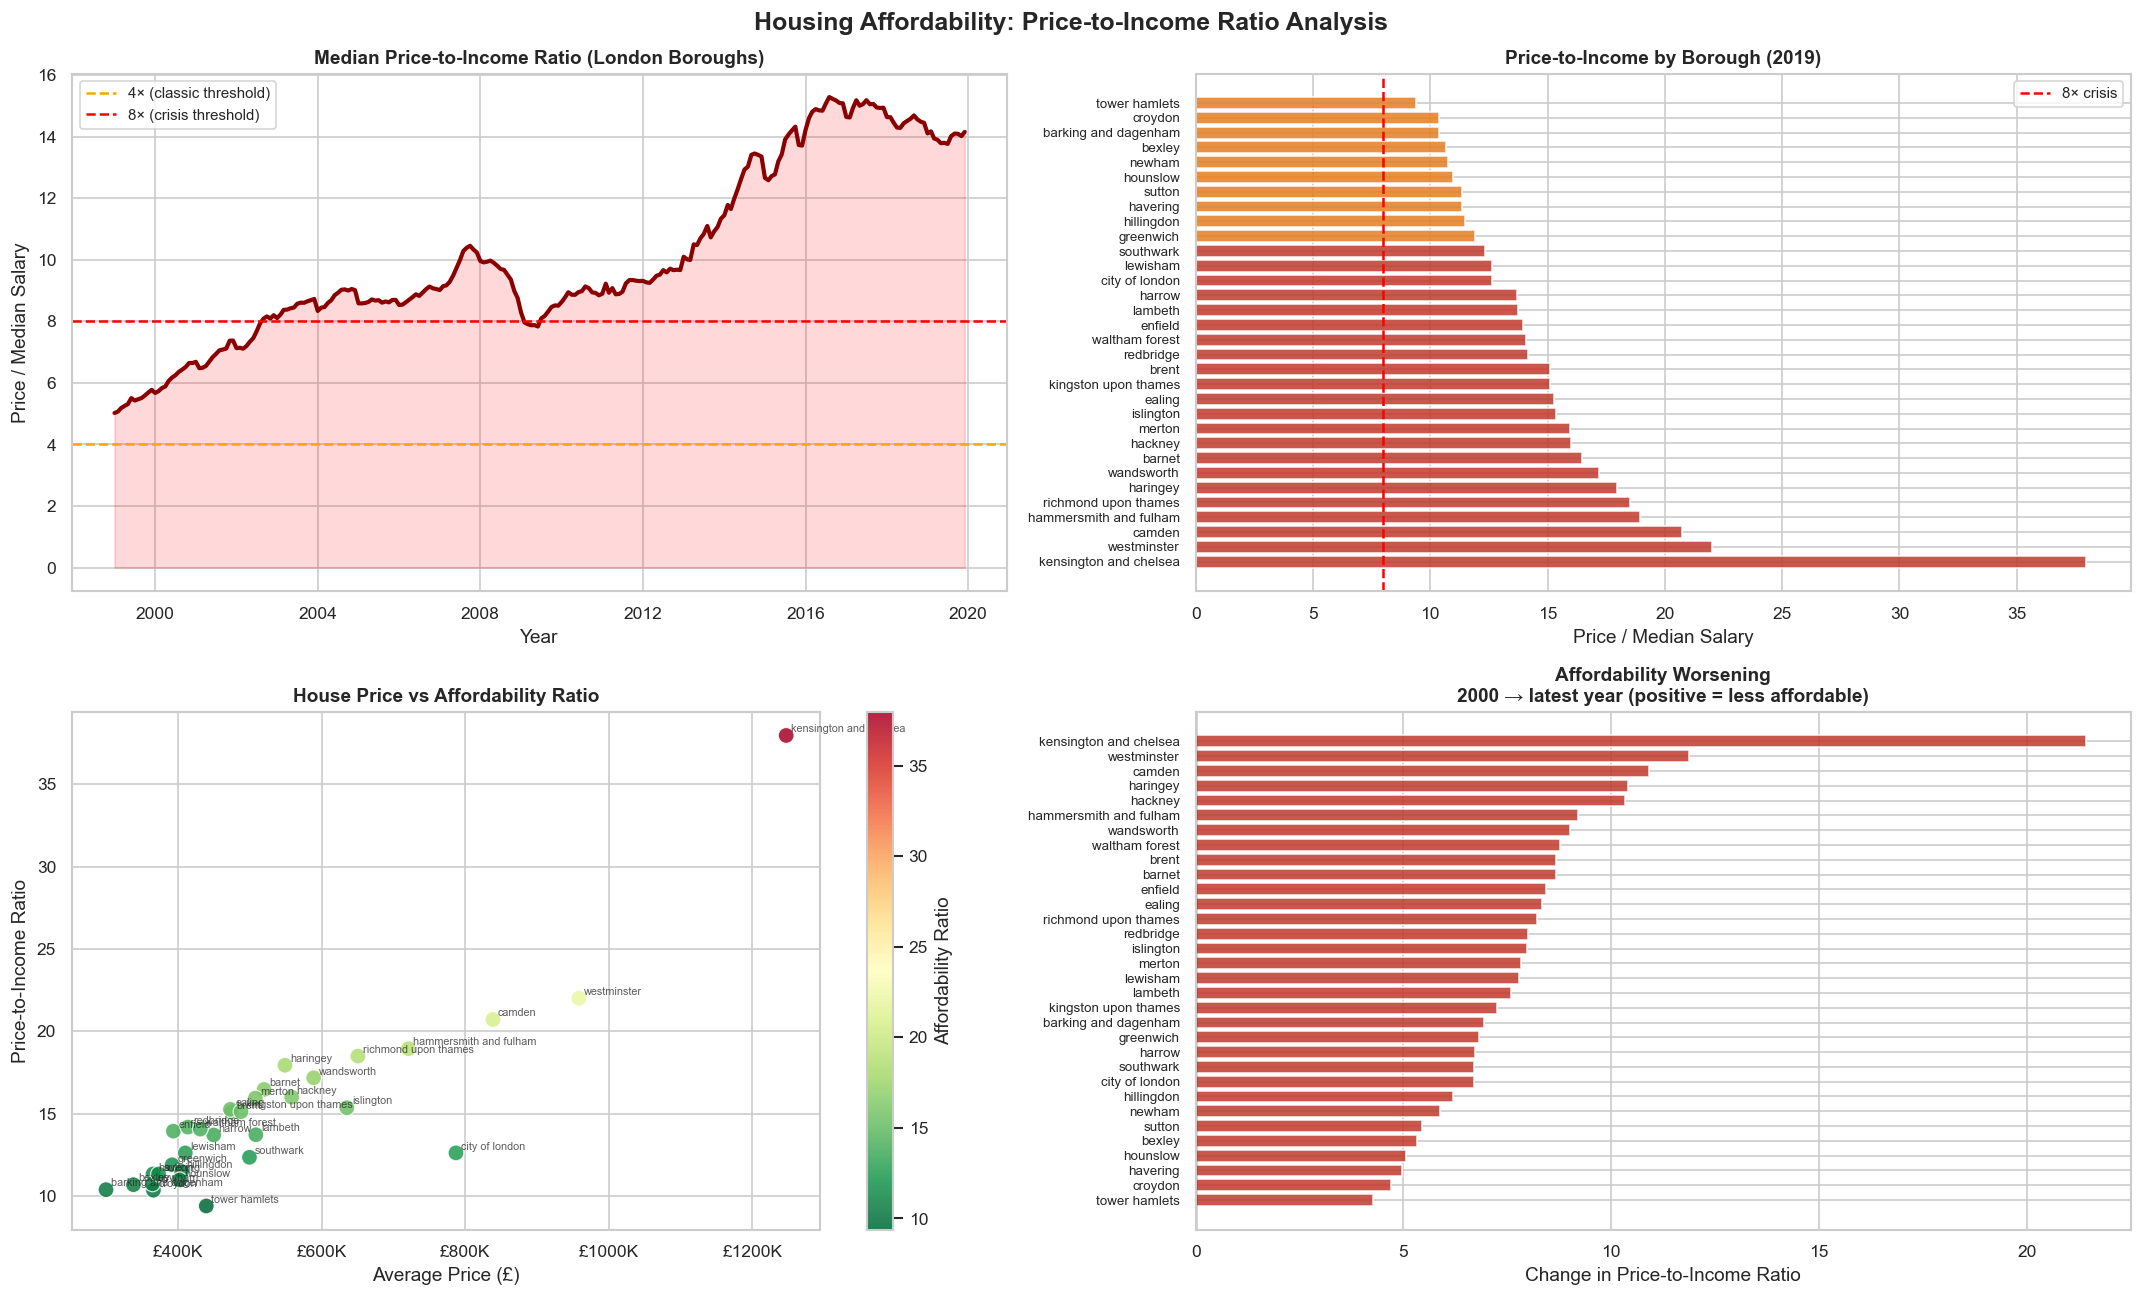

Most unaffordable borough : kensington and chelsea (38.0× median salary)
Most affordable borough   : tower hamlets (9.4× median salary)
Borough with fastest affordability deterioration: kensington and chelsea (+21.4× since 2000)


In [21]:
merged = (
    monthly[monthly['borough_flag'] == 1]
    .merge(
        yearly[yearly['borough_flag'] == 1][['area', 'year', 'median_salary']].dropna(),
        on=['area', 'year'], how='inner'
    )
)
merged['affordability'] = merged['average_price'] / merged['median_salary']

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle('Housing Affordability: Price-to-Income Ratio Analysis', fontsize=15, fontweight='bold')

# --- Affordability trend ---
ax1 = axes[0, 0]
aff_ts = merged.groupby('date')['affordability'].median()
ax1.plot(aff_ts.index, aff_ts.values, color='darkred', linewidth=2.5)
ax1.fill_between(aff_ts.index, aff_ts.values, alpha=0.15, color='red')
ax1.axhline(4, color='orange', linestyle='--', linewidth=1.5, label='4× (classic threshold)')
ax1.axhline(8, color='red', linestyle='--', linewidth=1.5, label='8× (crisis threshold)')
ax1.set_title('Median Price-to-Income Ratio (London Boroughs)', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Price / Median Salary')
ax1.legend(fontsize=9)

# --- Affordability by borough: latest ---
ax2 = axes[0, 1]
yr_latest = merged['year'].max()
aff_latest = (merged[merged['year'] == yr_latest]
              .groupby('area')['affordability'].median()
              .sort_values(ascending=False))
colors_aff = ['#c0392b' if v > 12 else '#e67e22' if v > 9
              else '#f1c40f' if v > 6 else '#27ae60' for v in aff_latest.values]
ax2.barh(range(len(aff_latest)), aff_latest.values, color=colors_aff, alpha=0.85)
ax2.set_yticks(range(len(aff_latest)))
ax2.set_yticklabels(aff_latest.index, fontsize=8)
ax2.axvline(8, color='red', linestyle='--', linewidth=1.5, label='8× crisis')
ax2.set_title(f'Price-to-Income by Borough ({yr_latest})', fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlabel('Price / Median Salary')

# --- Affordability vs price scatter ---
ax3 = axes[1, 0]
sc_data = (merged[merged['year'] == yr_latest]
           .groupby('area').agg({'average_price': 'mean', 'affordability': 'median'})
           .dropna())
sc = ax3.scatter(sc_data['average_price'], sc_data['affordability'],
                 c=sc_data['affordability'], cmap='RdYlGn_r', s=90,
                 alpha=0.85, edgecolors='white', linewidth=0.7)
plt.colorbar(sc, ax=ax3, label='Affordability Ratio')
for area, row in sc_data.iterrows():
    ax3.annotate(area, (row['average_price'], row['affordability']),
                 fontsize=6.5, alpha=0.75, xytext=(3, 2), textcoords='offset points')
ax3.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax3.set_title('House Price vs Affordability Ratio', fontweight='bold')
ax3.set_xlabel('Average Price (£)')
ax3.set_ylabel('Price-to-Income Ratio')

# --- Affordability worsening: 2000 vs latest ---
ax4 = axes[1, 1]
aff_2000 = merged[merged['year'] == 2000].groupby('area')['affordability'].median()
aff_now  = merged[merged['year'] == yr_latest].groupby('area')['affordability'].median()
aff_delta = (aff_now - aff_2000).dropna().sort_values()
ch_colors = ['#c0392b' if v > 0 else '#27ae60' for v in aff_delta.values]
ax4.barh(range(len(aff_delta)), aff_delta.values, color=ch_colors, alpha=0.85)
ax4.set_yticks(range(len(aff_delta)))
ax4.set_yticklabels(aff_delta.index, fontsize=8)
ax4.axvline(0, color='black', linewidth=0.8)
ax4.set_title('Affordability Worsening\n2000 → latest year (positive = less affordable)', fontweight='bold')
ax4.set_xlabel('Change in Price-to-Income Ratio')

plt.tight_layout()
plt.show()

worst_boro = aff_latest.idxmax()
print(f'Most unaffordable borough : {worst_boro} ({aff_latest[worst_boro]:.1f}× median salary)')
print(f'Most affordable borough   : {aff_latest.idxmin()} ({aff_latest.min():.1f}× median salary)')
print(f'Borough with fastest affordability deterioration: {aff_delta.idxmax()} (+{aff_delta.max():.1f}× since 2000)')

## 12 — Borough Clustering (K-Means + PCA)

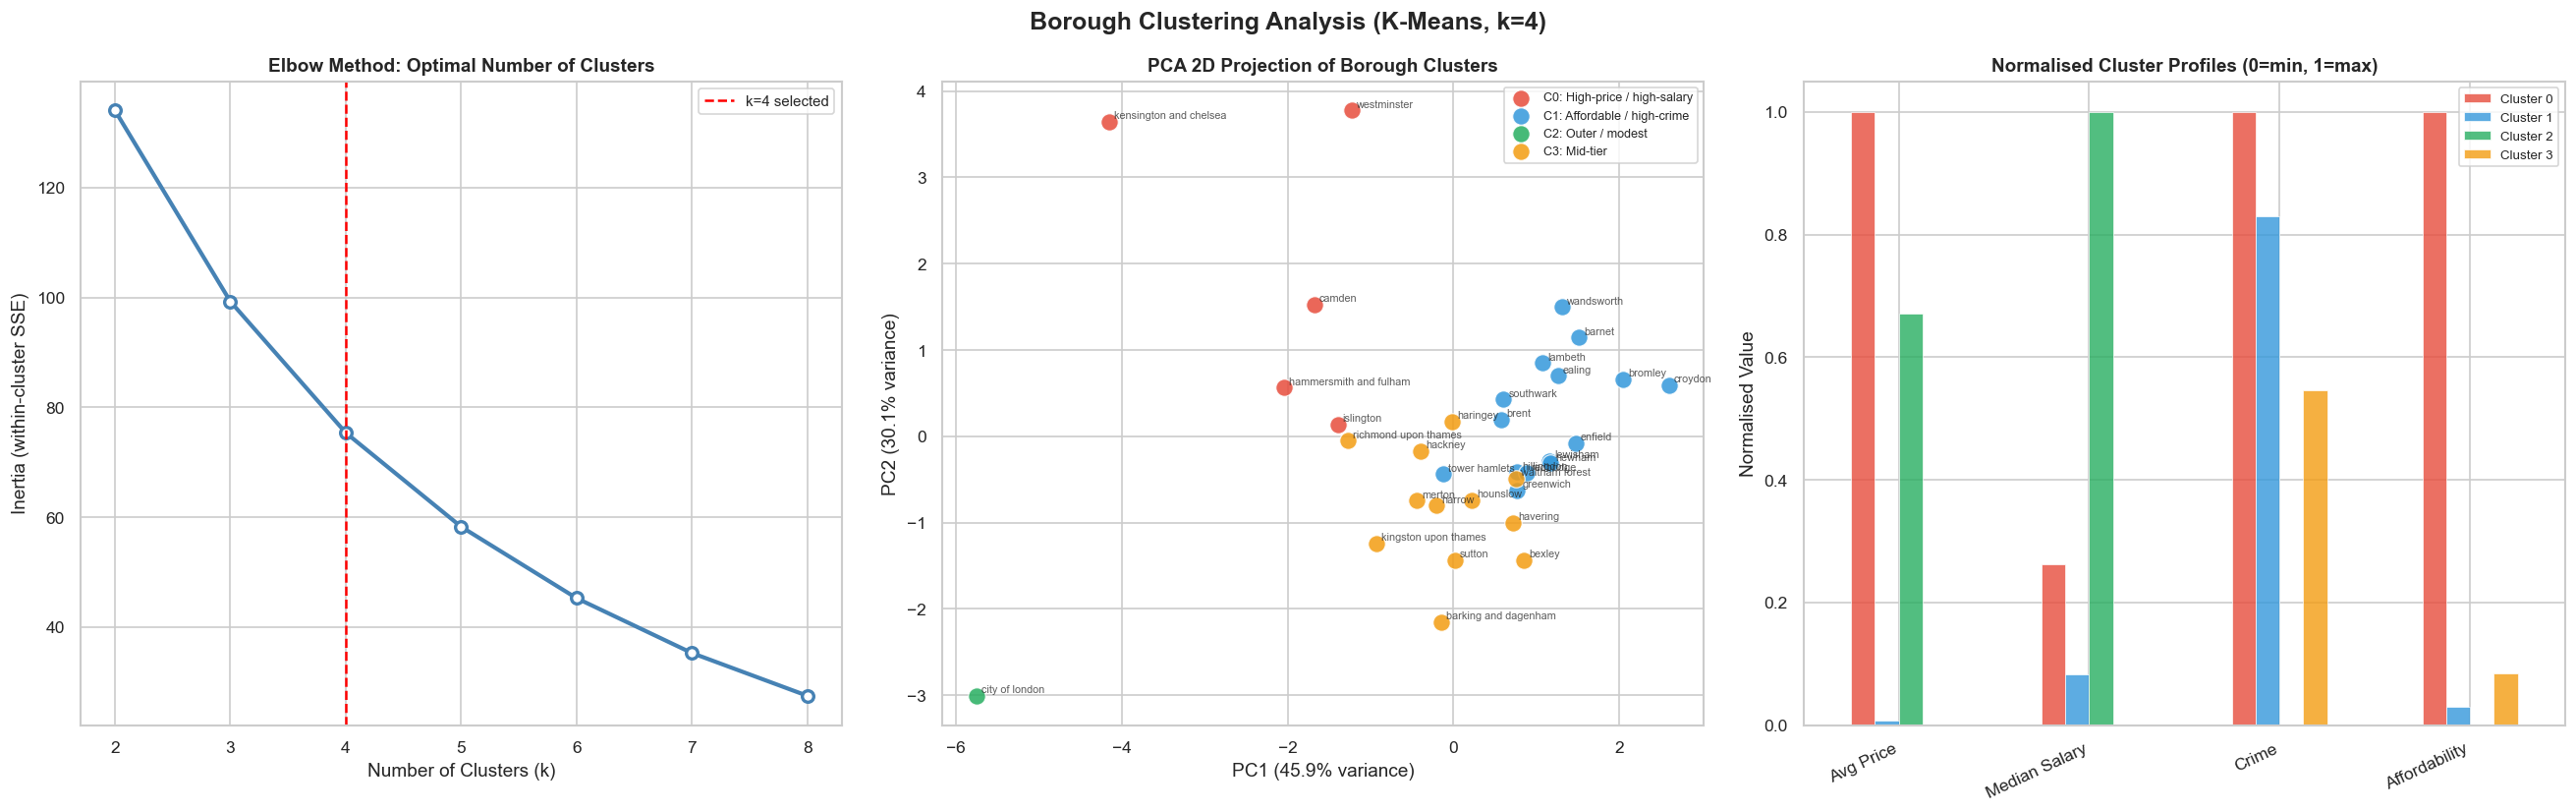

Cluster Summary (raw values):
         avg_price  median_salary  no_of_crimes  affordability
cluster                                                       
0         578920.0        32991.0        2922.0           17.0
1         283443.0        29026.0        2424.0           10.0
2         480924.0        49237.0           0.0            9.0
3         281041.0        27212.0        1595.0           10.0

Boroughs per cluster:
  Cluster 0: camden, hammersmith and fulham, islington, kensington and chelsea, westminster
  Cluster 1: barnet, brent, bromley, croydon, ealing, enfield, greenwich, hillingdon, lambeth, lewisham, newham, redbridge, southwark, tower hamlets, wandsworth
  Cluster 2: city of london
  Cluster 3: barking and dagenham, bexley, hackney, haringey, harrow, havering, hounslow, kingston upon thames, merton, richmond upon thames, sutton, waltham forest


In [22]:
# Build feature matrix
feat = merged.groupby('area').agg(
    avg_price=('average_price', 'mean'),
    median_salary=('median_salary', 'mean'),
    affordability=('affordability', 'mean'),
    houses_sold=('houses_sold', 'mean')
)

crime_avg = monthly[monthly['borough_flag'] == 1].groupby('area')['no_of_crimes'].mean()
pop_avg   = yearly[yearly['borough_flag'] == 1].groupby('area')['population_size'].mean()
feat = feat.join(crime_avg).join(pop_avg).dropna()

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(feat)

# Elbow method
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_
            for k in range(2, 9)]

# Final model: k=4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
feat['cluster'] = km.fit_predict(X_scaled)

# PCA projection
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
feat['PC1'] = coords[:, 0]
feat['PC2'] = coords[:, 1]

CL_COLORS = ['#e74c3c', '#3498db', '#27ae60', '#f39c12']
CL_NAMES  = ['High-price / high-salary', 'Affordable / high-crime', 'Outer / modest', 'Mid-tier']

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Borough Clustering Analysis (K-Means, k=4)', fontsize=15, fontweight='bold')

# Elbow
axes[0].plot(range(2, 9), inertias, marker='o', color='steelblue', linewidth=2.5,
             markersize=7, markerfacecolor='white', markeredgewidth=2)
axes[0].axvline(4, color='red', linestyle='--', linewidth=1.5, label='k=4 selected')
axes[0].set_title('Elbow Method: Optimal Number of Clusters', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].legend(fontsize=9)

# PCA scatter
for c in range(4):
    mask = feat['cluster'] == c
    axes[1].scatter(feat.loc[mask, 'PC1'], feat.loc[mask, 'PC2'],
                    c=CL_COLORS[c], s=110, label=f'C{c}: {CL_NAMES[c]}',
                    alpha=0.85, edgecolors='white', linewidth=0.7)
    for area in feat[mask].index:
        axes[1].annotate(area, (feat.loc[area, 'PC1'], feat.loc[area, 'PC2']),
                         fontsize=6.5, alpha=0.75, xytext=(3, 2), textcoords='offset points')
ev = pca.explained_variance_ratio_
axes[1].set_title('PCA 2D Projection of Borough Clusters', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({ev[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({ev[1]*100:.1f}% variance)')
axes[1].legend(fontsize=7.5, loc='best')

# Cluster profile bar
profile = feat.groupby('cluster')[['avg_price', 'median_salary', 'no_of_crimes', 'affordability']].mean()
profile.columns = ['Avg Price', 'Median Salary', 'Crime', 'Affordability']
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
profile_norm.T.plot(kind='bar', ax=axes[2], color=CL_COLORS[:4], alpha=0.8,
                    edgecolor='white', linewidth=0.5)
axes[2].set_title('Normalised Cluster Profiles (0=min, 1=max)', fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=25, ha='right')
axes[2].legend([f'Cluster {i}' for i in range(4)], fontsize=8)
axes[2].set_ylabel('Normalised Value')

plt.tight_layout()
plt.show()

print('Cluster Summary (raw values):')
print(feat.groupby('cluster')[['avg_price','median_salary','no_of_crimes','affordability']].mean().round(0).to_string())
print('\nBoroughs per cluster:')
for c in range(4):
    b = feat[feat['cluster'] == c].index.tolist()
    print(f'  Cluster {c}: {", ".join(b)}')

## 13 — Correlation Analysis

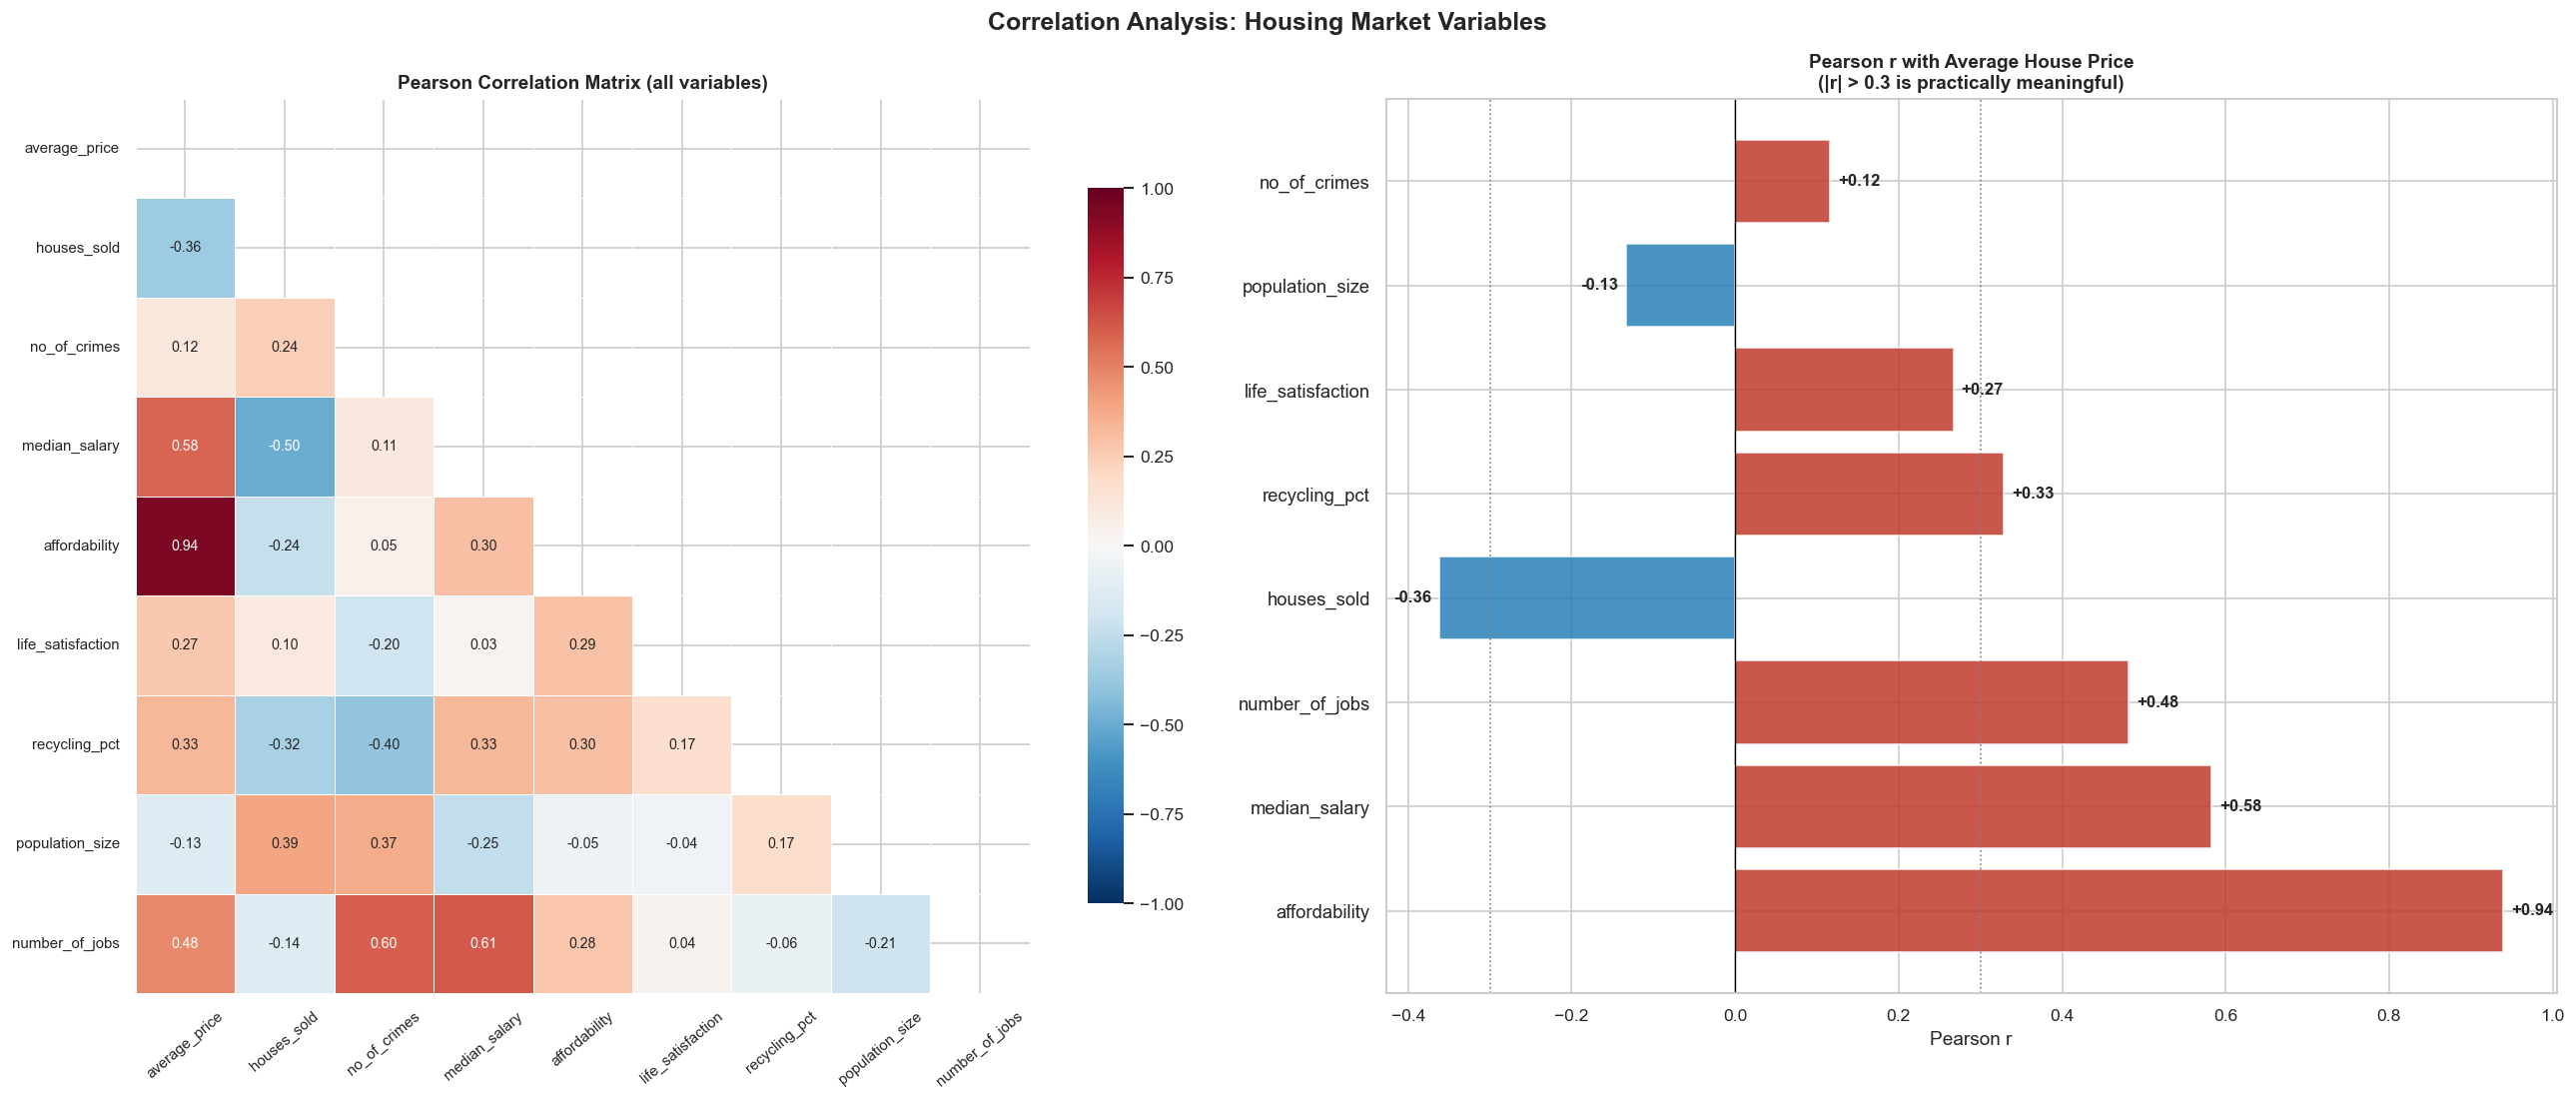

Correlations with average_price (sorted by absolute strength):
  affordability             r=+0.940  (strong positive)
  median_salary             r=+0.582  (moderate positive)
  number_of_jobs            r=+0.481  (moderate positive)
  houses_sold               r=-0.362  (moderate negative)
  recycling_pct             r=+0.329  (moderate positive)
  life_satisfaction         r=+0.267  (weak positive)
  population_size           r=-0.133  (weak negative)
  no_of_crimes              r=+0.116  (weak positive)


In [23]:
# Build merged panel for correlation
yearly_extra = (yearly[yearly['borough_flag'] == 1]
                [['area', 'year', 'life_satisfaction', 'recycling_pct',
                  'population_size', 'number_of_jobs']]
                .copy())
panel = merged.merge(yearly_extra, on=['area', 'year'], how='left')

num_cols = ['average_price', 'houses_sold', 'no_of_crimes', 'median_salary',
            'affordability', 'life_satisfaction', 'recycling_pct',
            'population_size', 'number_of_jobs']
corr = panel[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('Correlation Analysis: Housing Market Variables', fontsize=15, fontweight='bold')

# Full lower-triangle heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[0], cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5,
            linecolor='white', vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8}, annot_kws={'fontsize': 8.5})
axes[0].set_title('Pearson Correlation Matrix (all variables)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=40, labelsize=9)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)

# Strongest correlates with price
price_corr = corr['average_price'].drop('average_price').sort_values(key=abs, ascending=False)
cbar_colors = ['#c0392b' if v > 0 else '#2980b9' for v in price_corr.values]
axes[1].barh(range(len(price_corr)), price_corr.values, color=cbar_colors, alpha=0.85)
axes[1].set_yticks(range(len(price_corr)))
axes[1].set_yticklabels(price_corr.index, fontsize=11)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline(0.3, color='gray', linestyle=':', linewidth=1)
axes[1].axvline(-0.3, color='gray', linestyle=':', linewidth=1)
axes[1].set_title('Pearson r with Average House Price\n(|r| > 0.3 is practically meaningful)', fontweight='bold')
axes[1].set_xlabel('Pearson r')
for i, v in enumerate(price_corr.values):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i, f'{v:+.2f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('Correlations with average_price (sorted by absolute strength):')
for var, r in price_corr.items():
    strength = 'strong' if abs(r) > 0.6 else 'moderate' if abs(r) > 0.3 else 'weak'
    direction = 'positive' if r > 0 else 'negative'
    print(f'  {var:<25} r={r:+.3f}  ({strength} {direction})')

## 14 — Key Relationship Scatter Plots

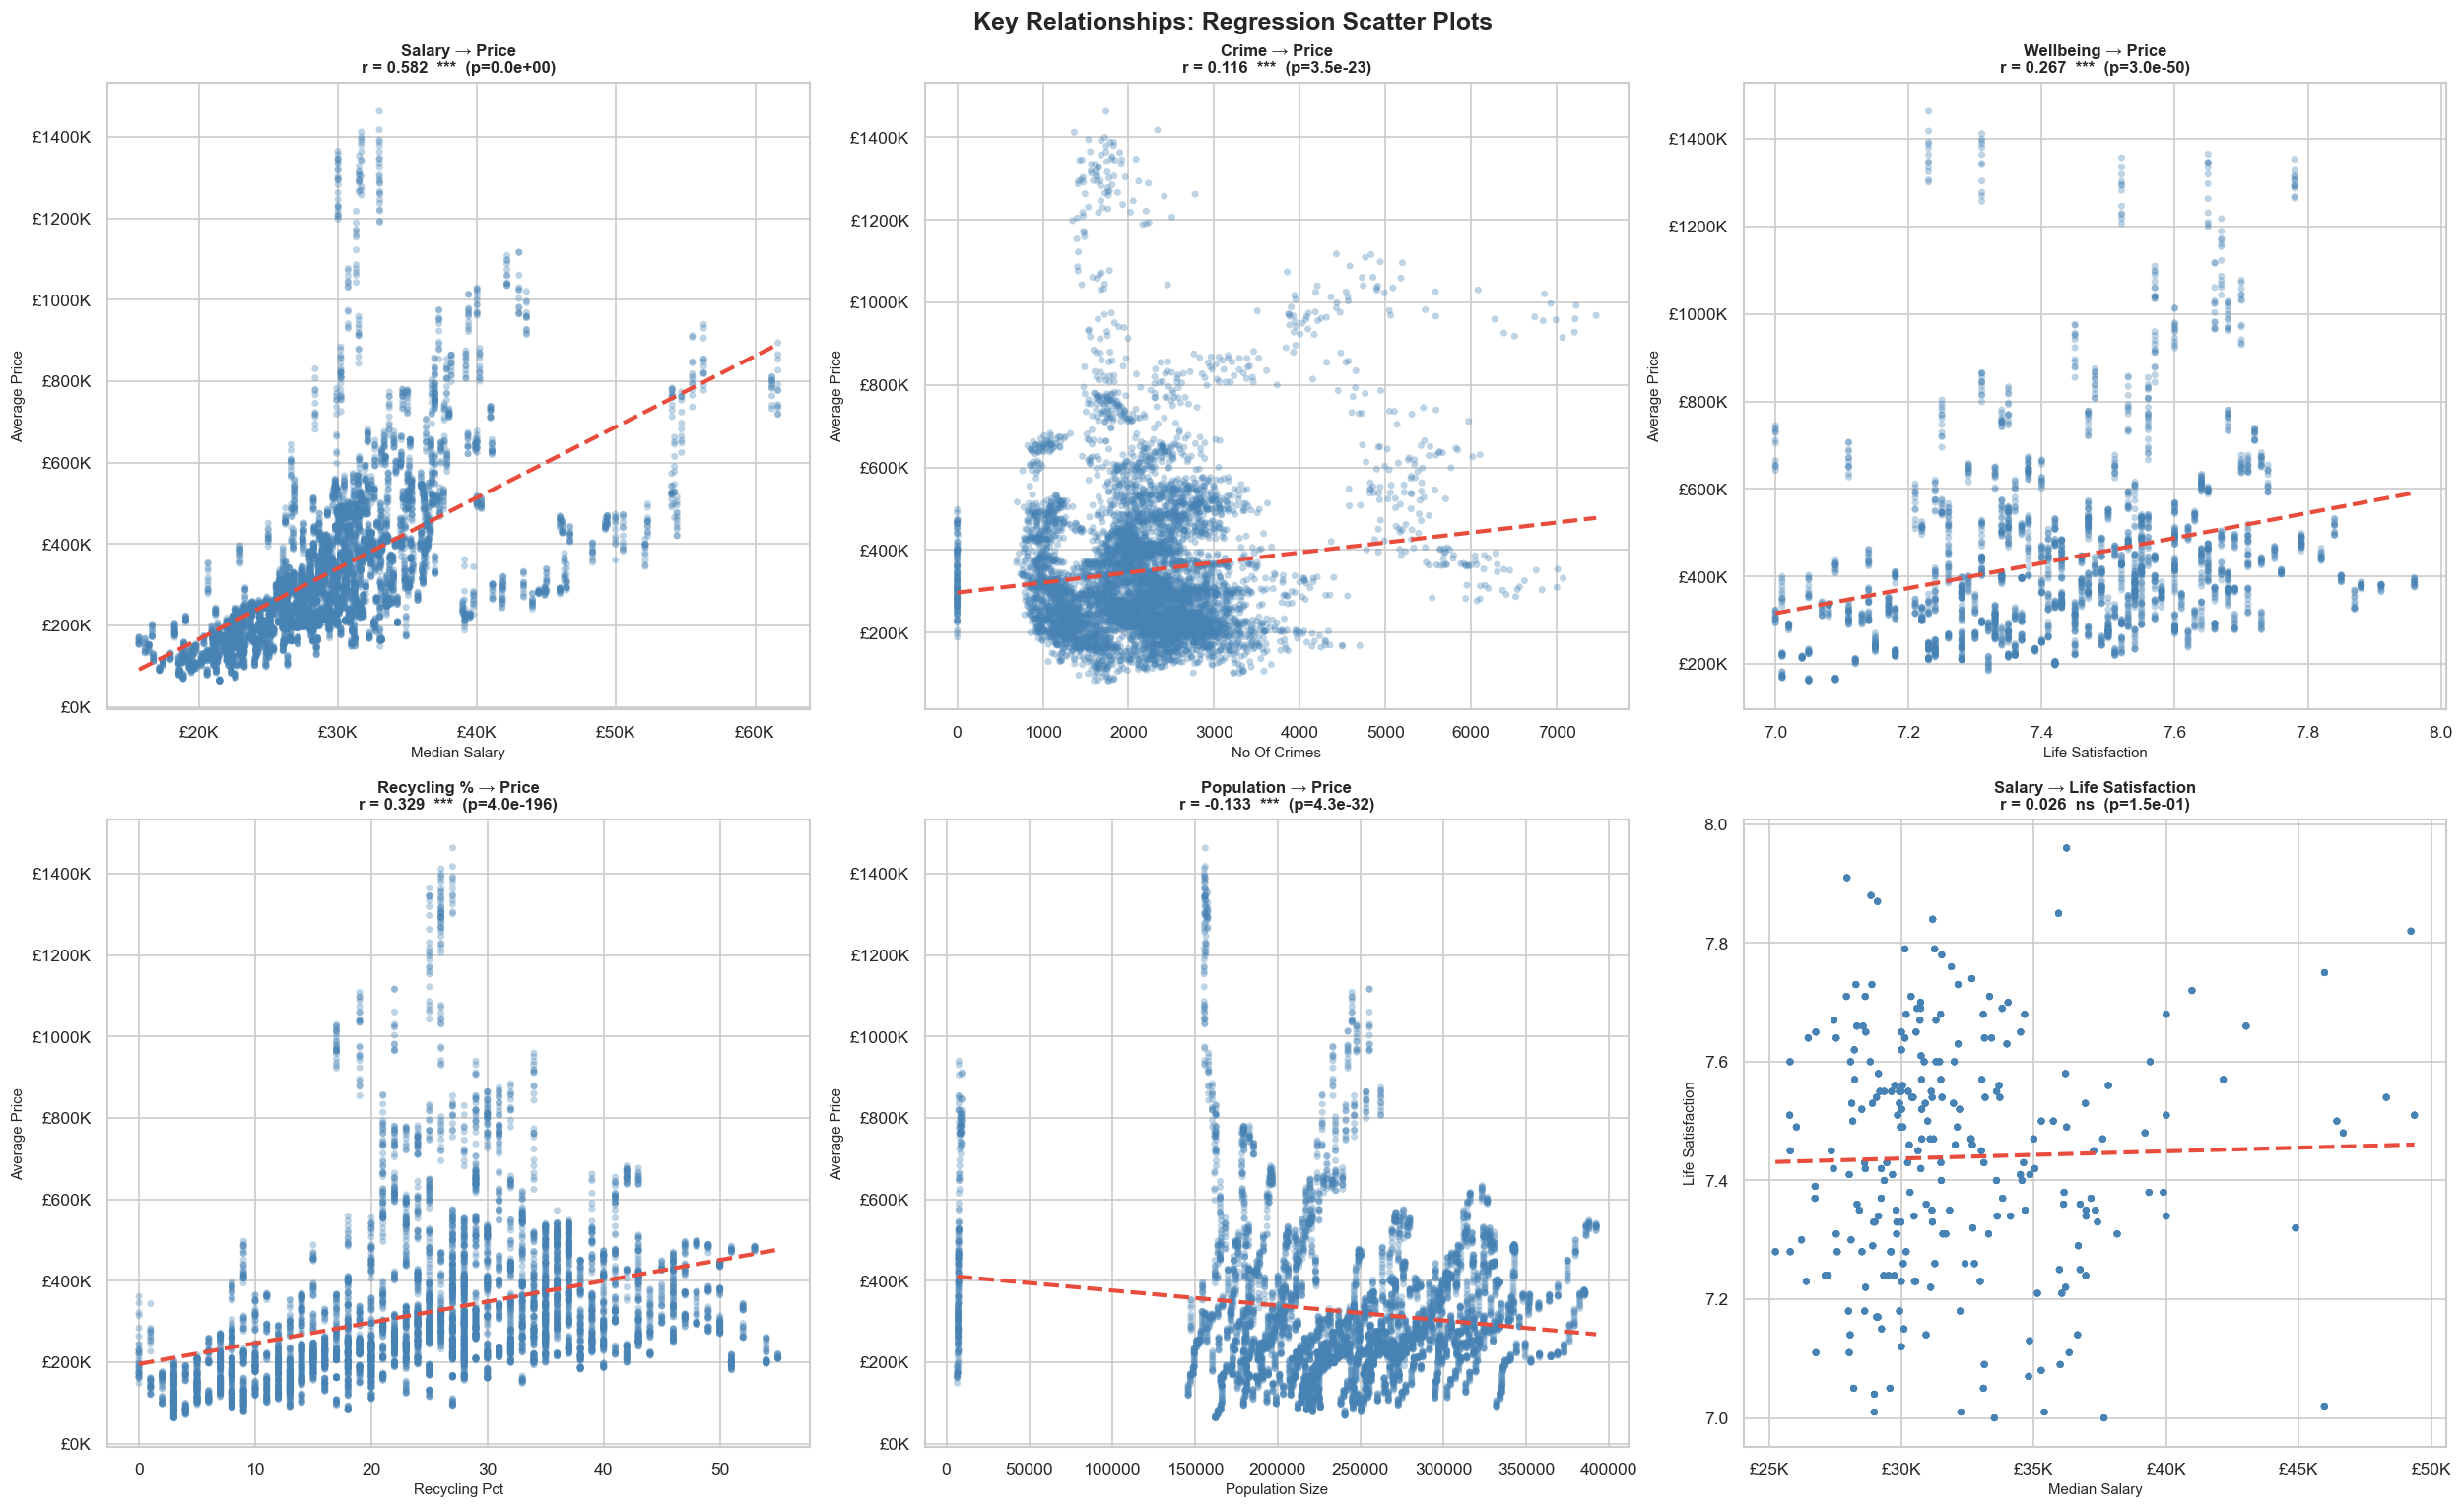

In [24]:
scatter_specs = [
    ('median_salary',    'average_price',     'Salary → Price',          True,  True),
    ('no_of_crimes',     'average_price',     'Crime → Price',           False, True),
    ('life_satisfaction','average_price',     'Wellbeing → Price',       False, True),
    ('recycling_pct',    'average_price',     'Recycling % → Price',     False, True),
    ('population_size',  'average_price',     'Population → Price',      False, True),
    ('median_salary',    'life_satisfaction', 'Salary → Life Satisfaction', True, False),
]

fig, axes = plt.subplots(2, 3, figsize=(21, 13))
fig.suptitle('Key Relationships: Regression Scatter Plots', fontsize=15, fontweight='bold')

for ax, (xcol, ycol, title, fmt_x, fmt_y) in zip(axes.flatten(), scatter_specs):
    d = panel[[xcol, ycol]].dropna()
    ax.scatter(d[xcol], d[ycol], alpha=0.35, s=18, color='steelblue', edgecolors='none')
    slope, intercept, r, p, _ = stats.linregress(d[xcol], d[ycol])
    xfit = np.linspace(d[xcol].min(), d[xcol].max(), 200)
    ax.plot(xfit, slope * xfit + intercept, color='#e74c3c', linewidth=2.5, linestyle='--')
    sig_label = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.set_title(f'{title}\nr = {r:.3f}  {sig_label}  (p={p:.1e})', fontweight='bold', fontsize=10)
    ax.set_xlabel(xcol.replace('_', ' ').title(), fontsize=9)
    ax.set_ylabel(ycol.replace('_', ' ').title(), fontsize=9)
    if fmt_y:
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
    if fmt_x:
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

## 15 — Time Series Decomposition & Stationarity

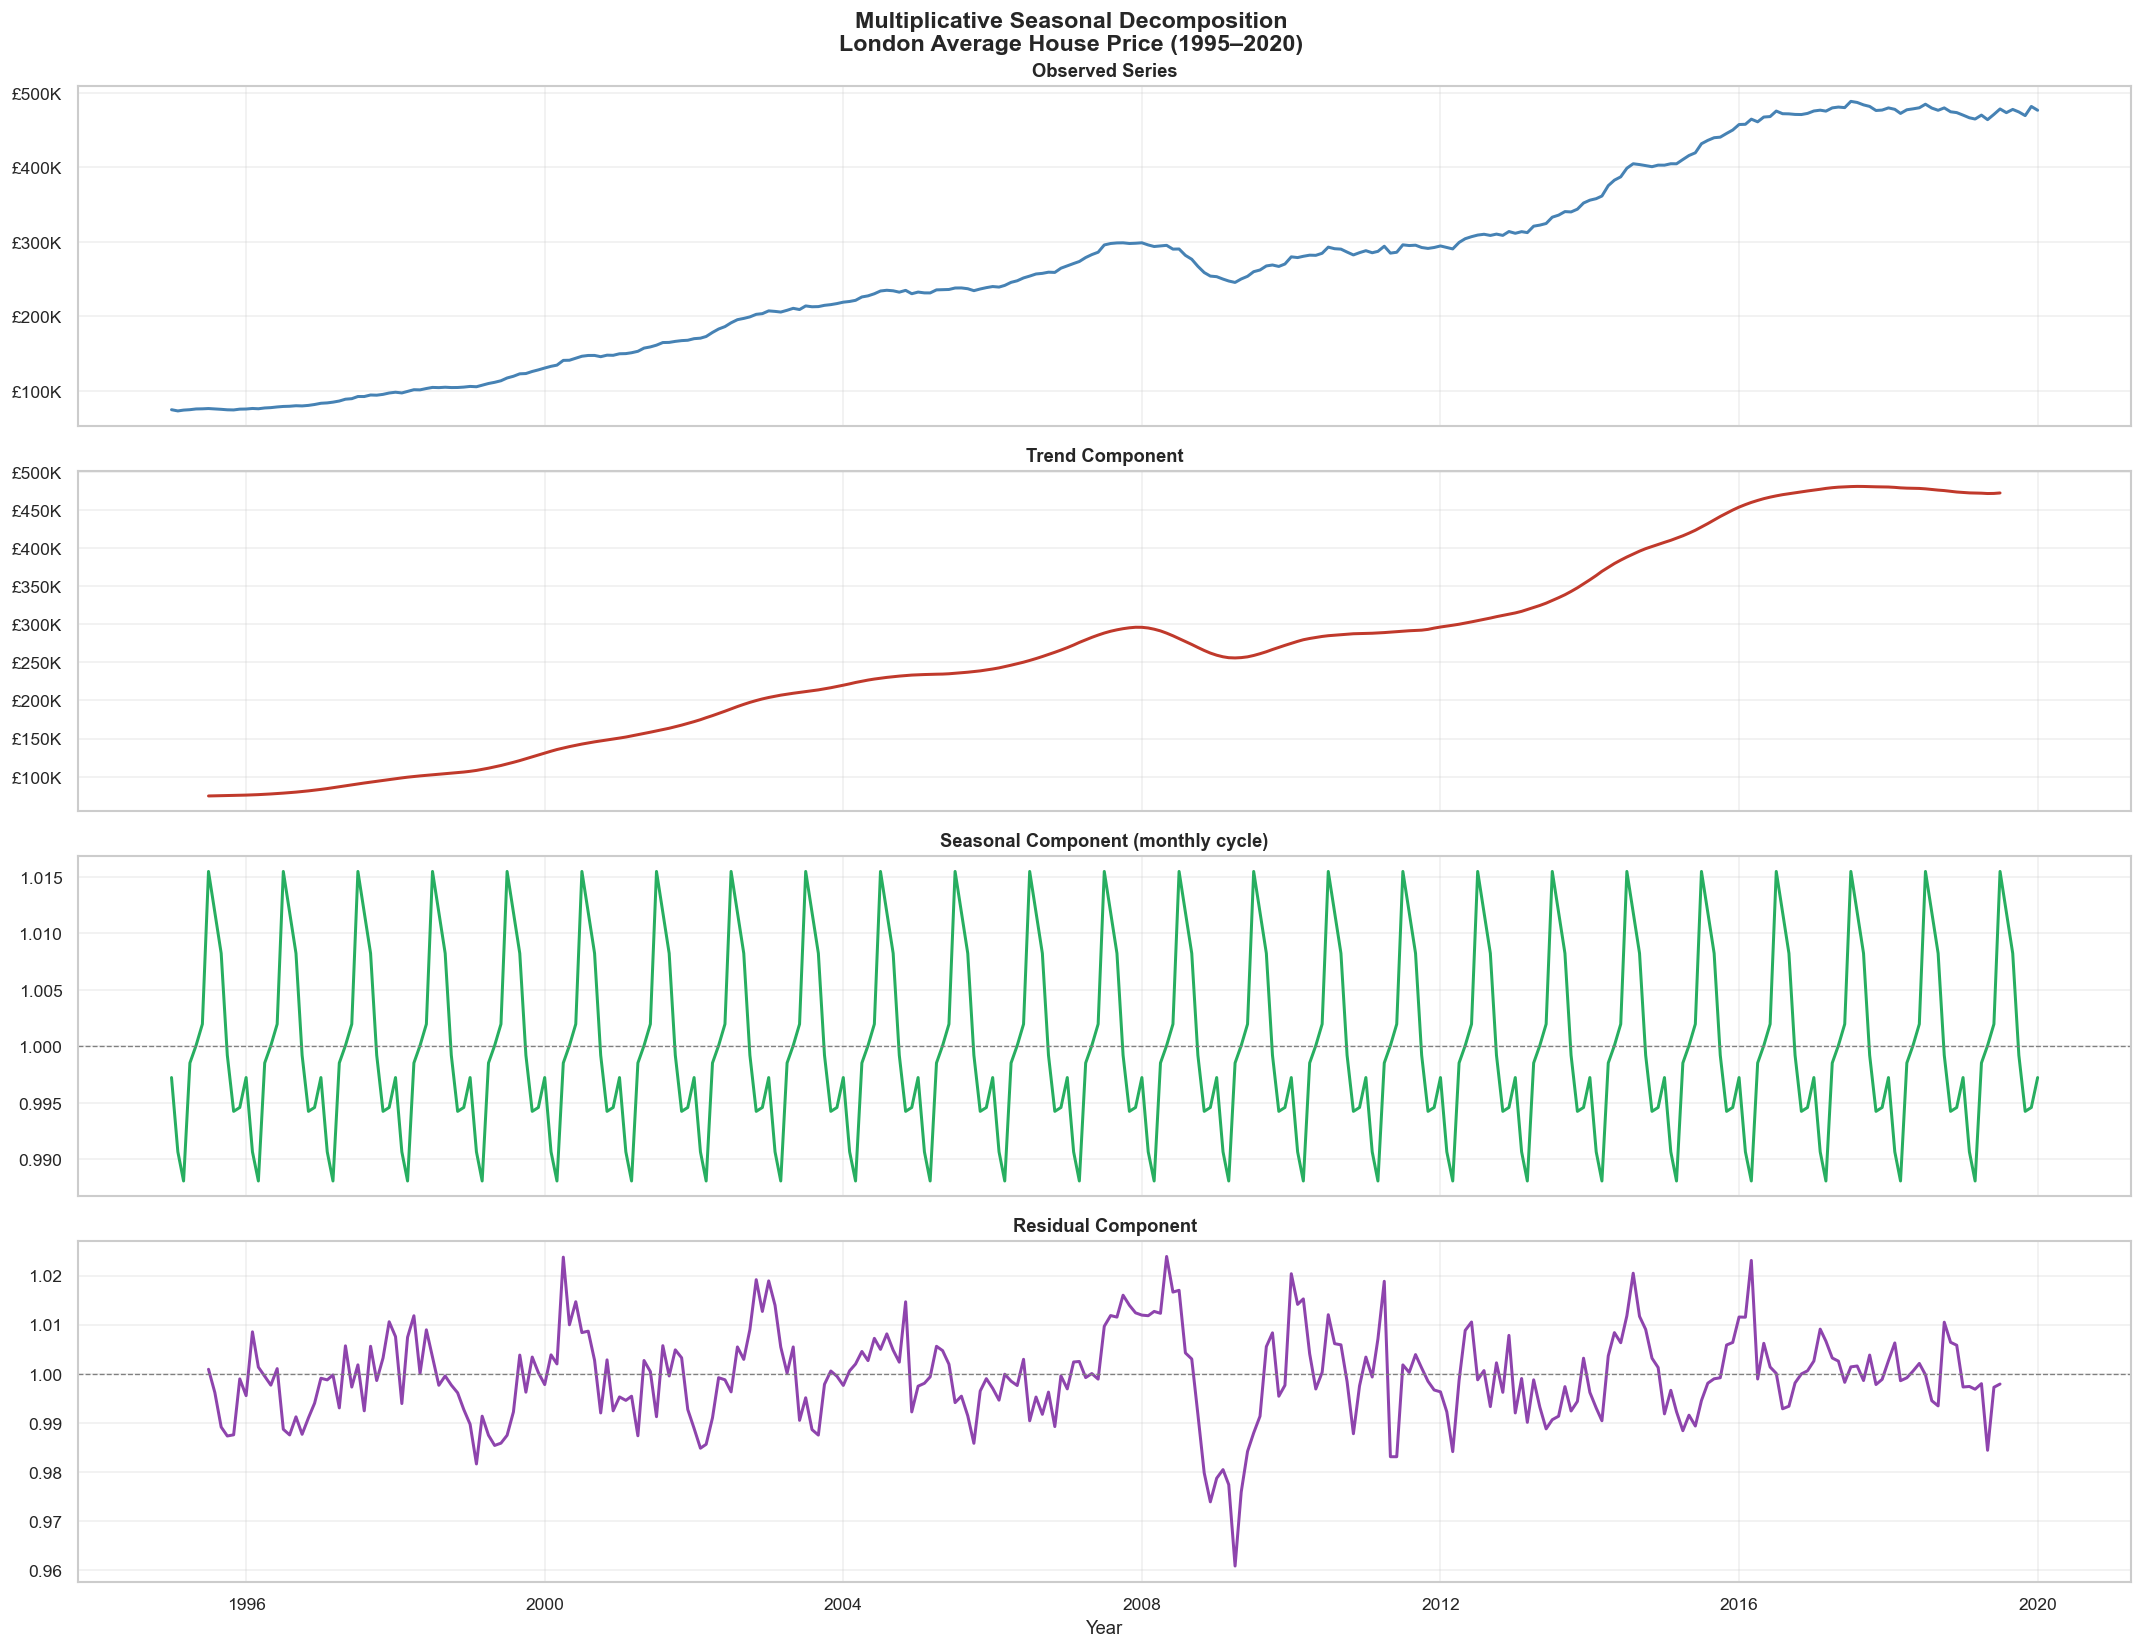


ADF Unit Root Tests:
---------------------------------------------------------------------------
Original series                           ADF=-0.162  p=0.9429  [NON-STATIONARY]
1st difference                            ADF=-4.687  p=0.0001  [STATIONARY]
1st + seasonal (12) difference            ADF=-4.274  p=0.0005  [STATIONARY]

Seasonal index (multiplicative):
  Jan: 0.9972  ░
  Feb: 0.9906  ░░░░
  Mar: 0.9881  ░░░░░
  Apr: 0.9985  
  May: 1.0001  ▓▓▓▓▓
  Jun: 1.0020  ▓▓▓▓▓
  Jul: 1.0155  ▓▓▓▓▓▓▓▓▓▓▓▓
  Aug: 1.0118  ▓▓▓▓▓▓▓▓▓▓
  Sep: 1.0082  ▓▓▓▓▓▓▓▓▓
  Oct: 0.9992  
  Nov: 0.9942  ░░
  Dec: 0.9946  ░░


In [25]:
ts_raw = (monthly[monthly['area'] == 'london']
          .set_index('date')['average_price']
          .dropna()
          .asfreq('MS'))

decomp = seasonal_decompose(ts_raw, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)
fig.suptitle('Multiplicative Seasonal Decomposition\nLondon Average House Price (1995–2020)',
             fontsize=14, fontweight='bold')

component_info = [
    (ts_raw,         'steelblue',   'Observed Series',                    True),
    (decomp.trend,   '#c0392b',     'Trend Component',                    True),
    (decomp.seasonal,'#27ae60',     'Seasonal Component (monthly cycle)', False),
    (decomp.resid,   '#8e44ad',     'Residual Component',                 False),
]

for ax, (series, color, label, fmt_price) in zip(axes, component_info):
    ax.plot(series.index, series.values, color=color, linewidth=1.8)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.3)
    if fmt_price:
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
    else:
        ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)

axes[-1].set_xlabel('Year', fontsize=11)
plt.tight_layout()
plt.show()

# --- ADF Stationarity Test ---
def adf_report(series, label):
    res = adfuller(series.dropna(), autolag='AIC')
    status = 'STATIONARY' if res[1] < 0.05 else 'NON-STATIONARY'
    print(f'{label:<40}  ADF={res[0]:+.3f}  p={res[1]:.4f}  [{status}]')
    return res[1]

print('\nADF Unit Root Tests:')
print('-' * 75)
adf_report(ts_raw,              'Original series')
adf_report(ts_raw.diff(),       '1st difference')
adf_report(ts_raw.diff().diff(12), '1st + seasonal (12) difference')

# Seasonal index
seas_idx = decomp.seasonal.groupby(decomp.seasonal.index.month).mean()
print('\nSeasonal index (multiplicative):')
month_names_short = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for m, idx in zip(month_names_short, seas_idx.values):
    bar = '▓' * int((idx - 0.99) * 500) if idx > 1 else '░' * int((1 - idx) * 500)
    print(f'  {m}: {idx:.4f}  {bar}')

## 16 — ACF / PACF for SARIMA Order Selection

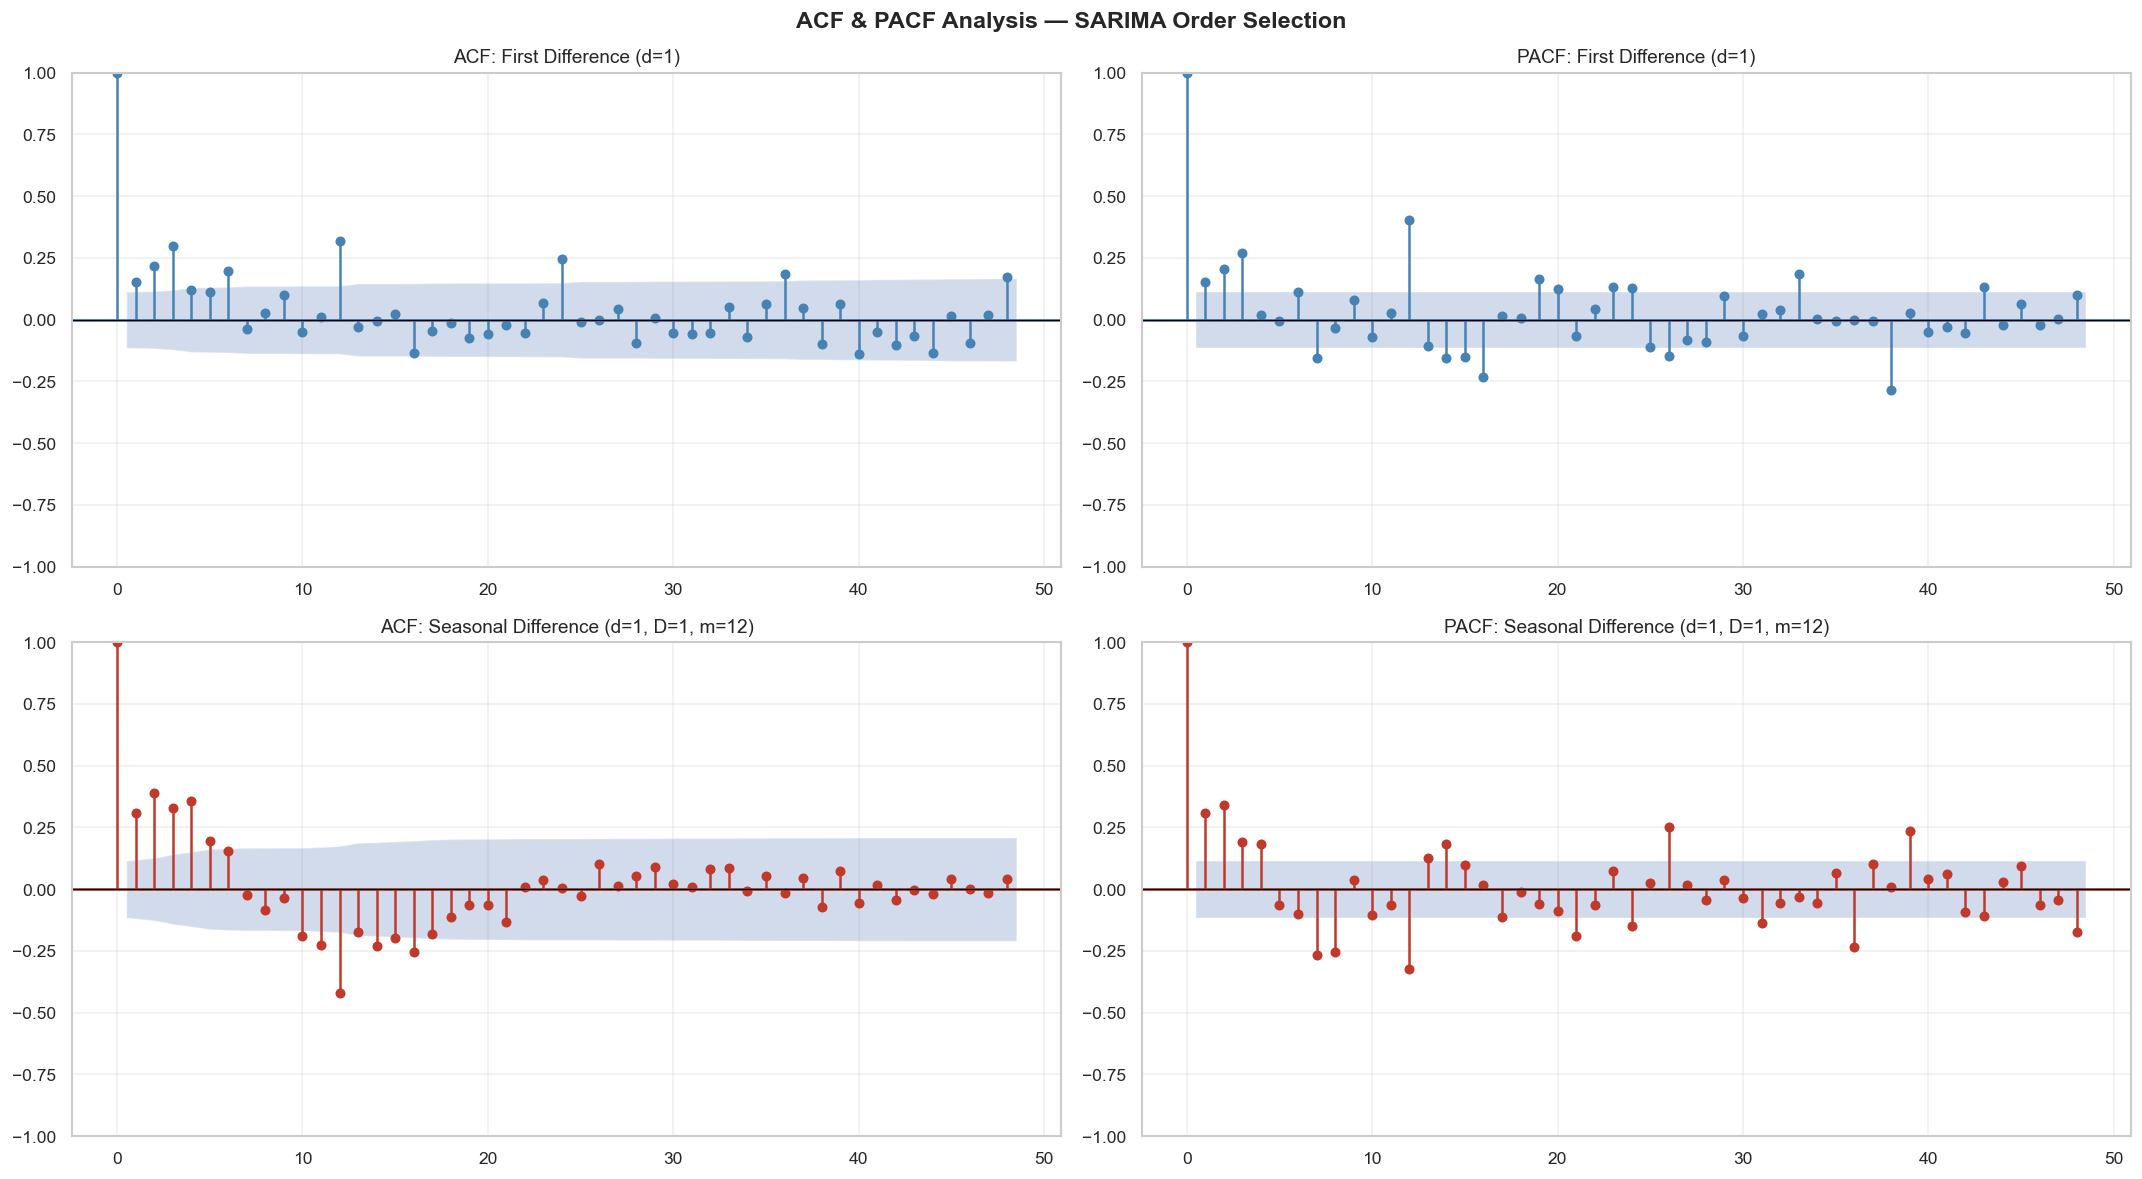

ACF/PACF reading:
  Non-seasonal: ACF cuts off at lag 1 (q=1), PACF cuts off at lag 1 (p=1) → ARIMA(1,1,1)
  Seasonal    : spikes at lags 12/24 suggest SAR/SMA(1) → SARIMA(1,1,1)(1,1,1,12)


In [26]:
ts_d1    = ts_raw.diff().dropna()
ts_d1_D1 = ts_d1.diff(12).dropna()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('ACF & PACF Analysis — SARIMA Order Selection', fontsize=14, fontweight='bold')

plot_acf(ts_d1, lags=48, ax=axes[0, 0],
         title='ACF: First Difference (d=1)',
         color='steelblue', vlines_kwargs={'colors': 'steelblue'})
plot_pacf(ts_d1, lags=48, ax=axes[0, 1], method='ols',
          title='PACF: First Difference (d=1)',
          color='steelblue', vlines_kwargs={'colors': 'steelblue'})
plot_acf(ts_d1_D1, lags=48, ax=axes[1, 0],
         title='ACF: Seasonal Difference (d=1, D=1, m=12)',
         color='#c0392b', vlines_kwargs={'colors': '#c0392b'})
plot_pacf(ts_d1_D1, lags=48, ax=axes[1, 1], method='ols',
          title='PACF: Seasonal Difference (d=1, D=1, m=12)',
          color='#c0392b', vlines_kwargs={'colors': '#c0392b'})

for ax in axes.flatten():
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print('ACF/PACF reading:')
print('  Non-seasonal: ACF cuts off at lag 1 (q=1), PACF cuts off at lag 1 (p=1) → ARIMA(1,1,1)')
print('  Seasonal    : spikes at lags 12/24 suggest SAR/SMA(1) → SARIMA(1,1,1)(1,1,1,12)')

## 17 — SARIMA Forecasting

In [27]:
train = ts_raw[:'2017-12-01']
test  = ts_raw['2018-01-01':]

print(f'Train: {len(train)} months ({train.index[0].date()} – {train.index[-1].date()})')
print(f'Test : {len(test)} months  ({test.index[0].date()} – {test.index[-1].date()})')
print('Fitting SARIMA(1,1,1)(1,1,1,12)...')

model  = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                 enforce_stationarity=False, enforce_invertibility=False)
result = model.fit(disp=False)
print(result.summary())

Train: 276 months (1995-01-01 – 2017-12-01)
Test : 25 months  (2018-01-01 – 2020-01-01)
Fitting SARIMA(1,1,1)(1,1,1,12)...
                                     SARIMAX Results                                      
Dep. Variable:                      average_price   No. Observations:                  276
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2342.650
Date:                            Sat, 23 May 2026   AIC                           4695.300
Time:                                    02:23:18   BIC                           4712.887
Sample:                                01-01-1995   HQIC                          4702.379
                                     - 12-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

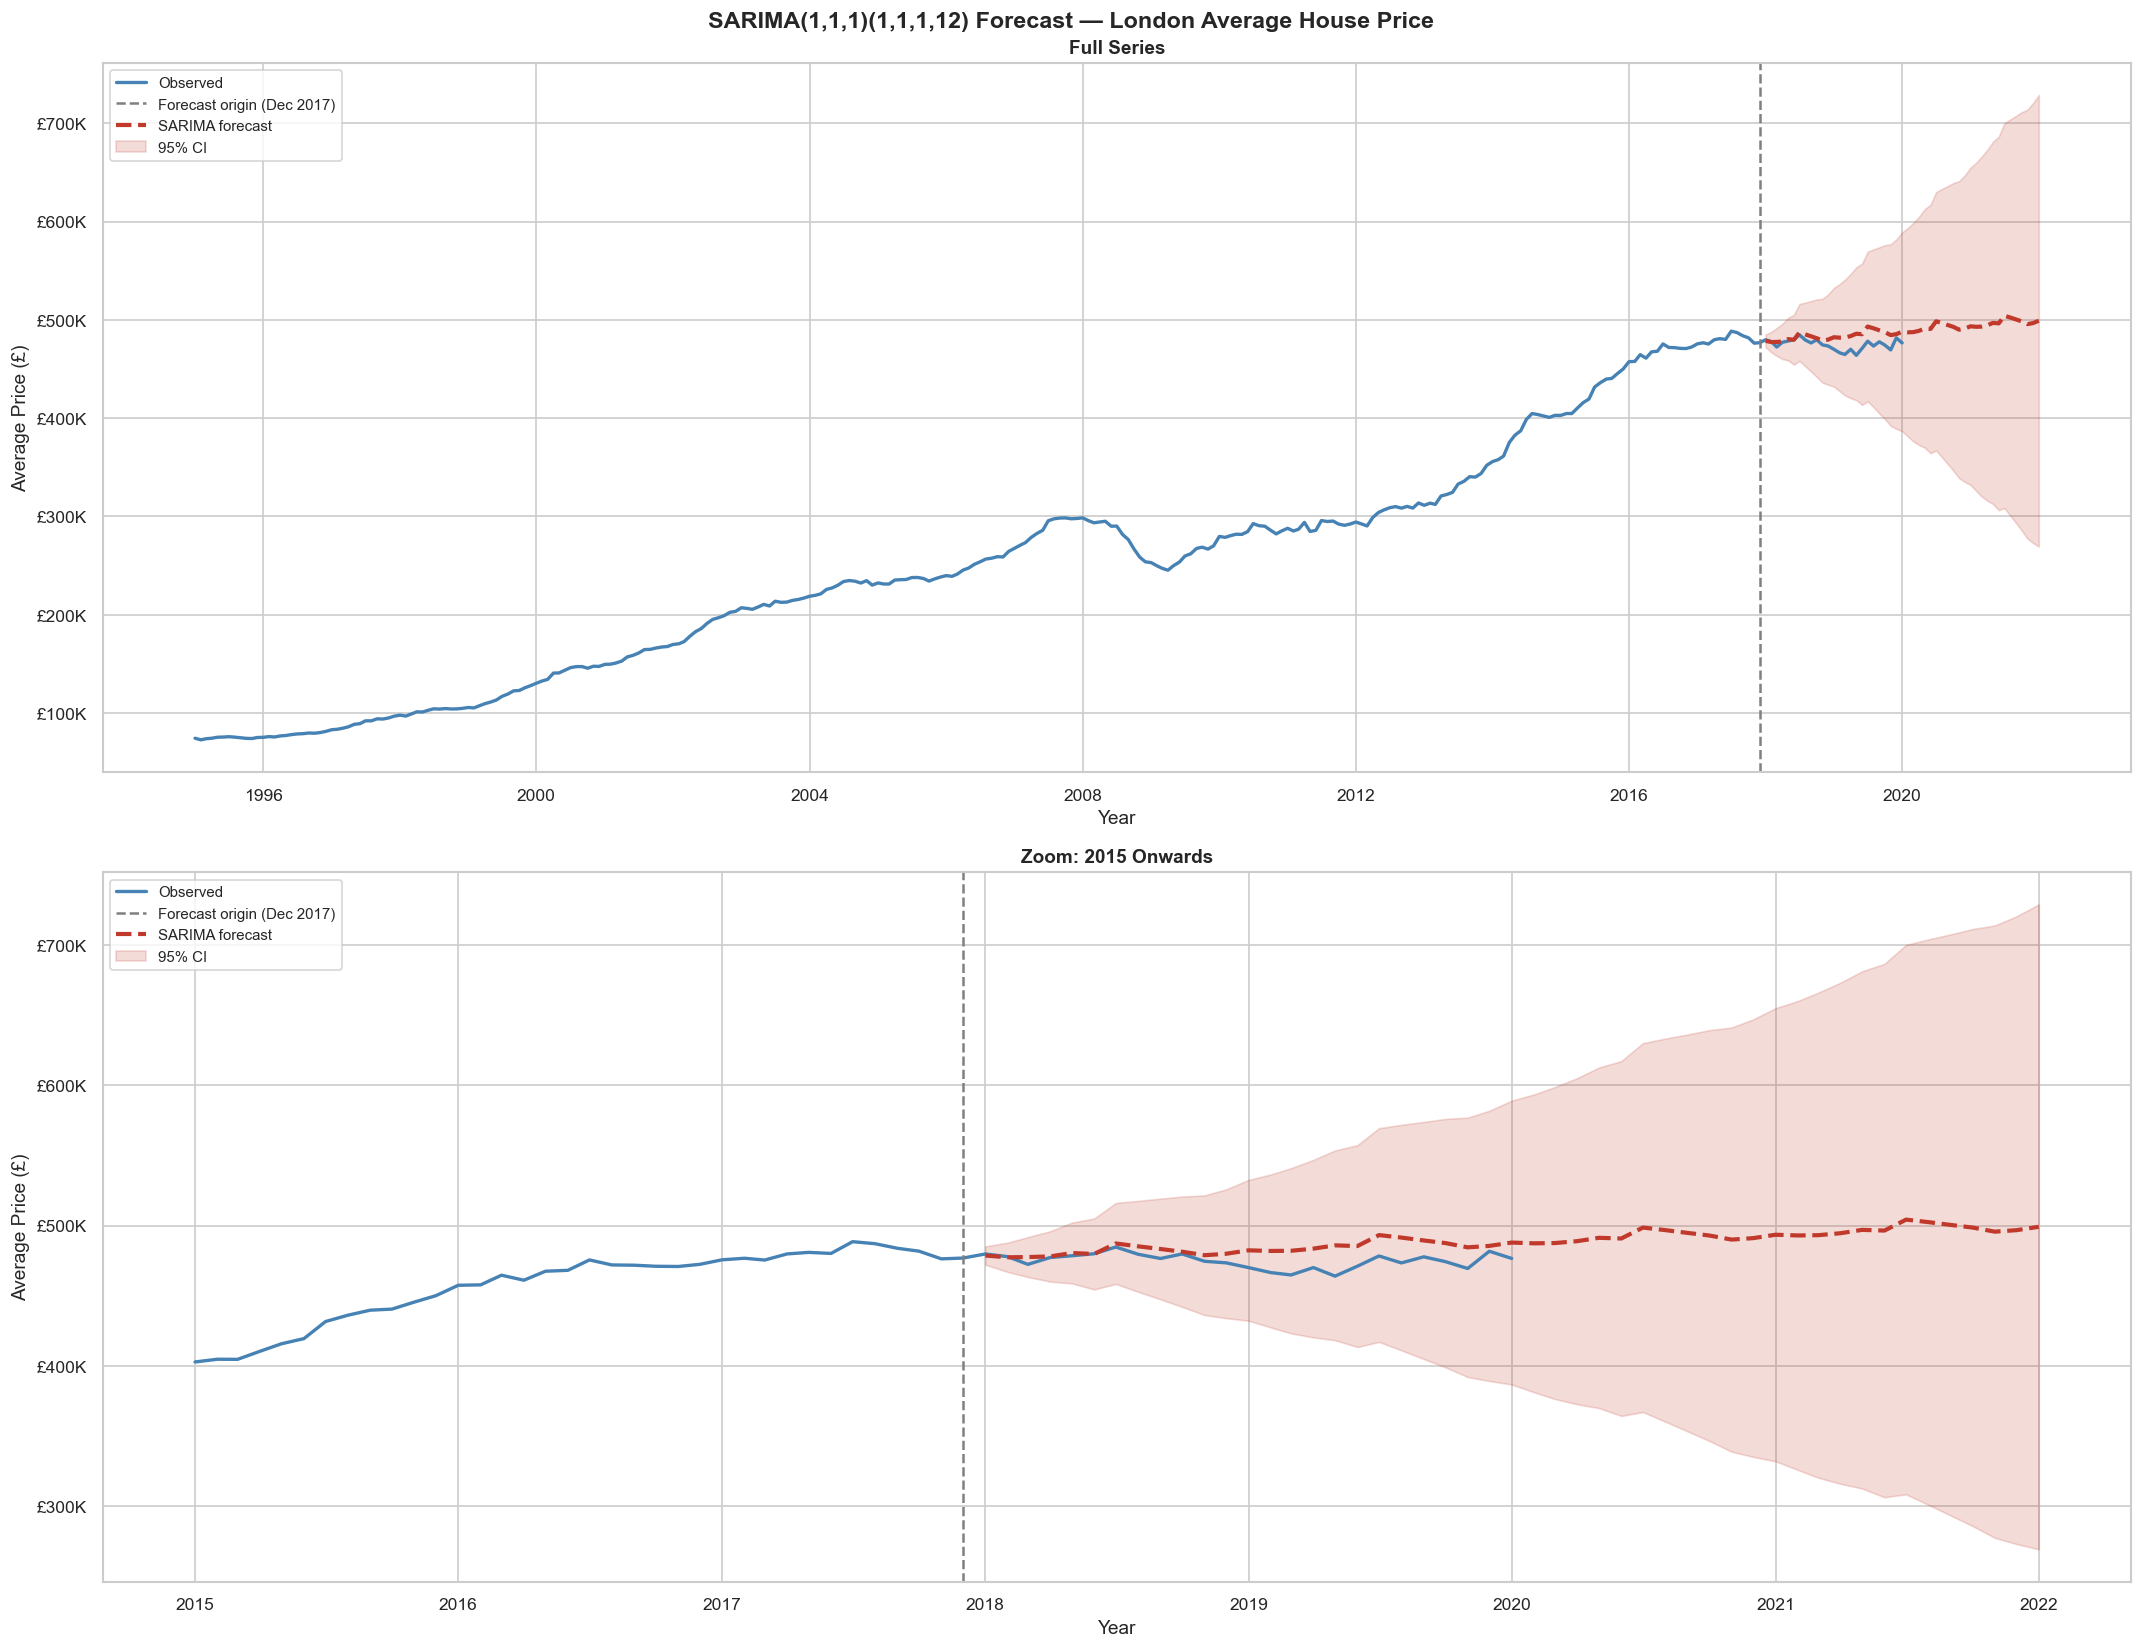

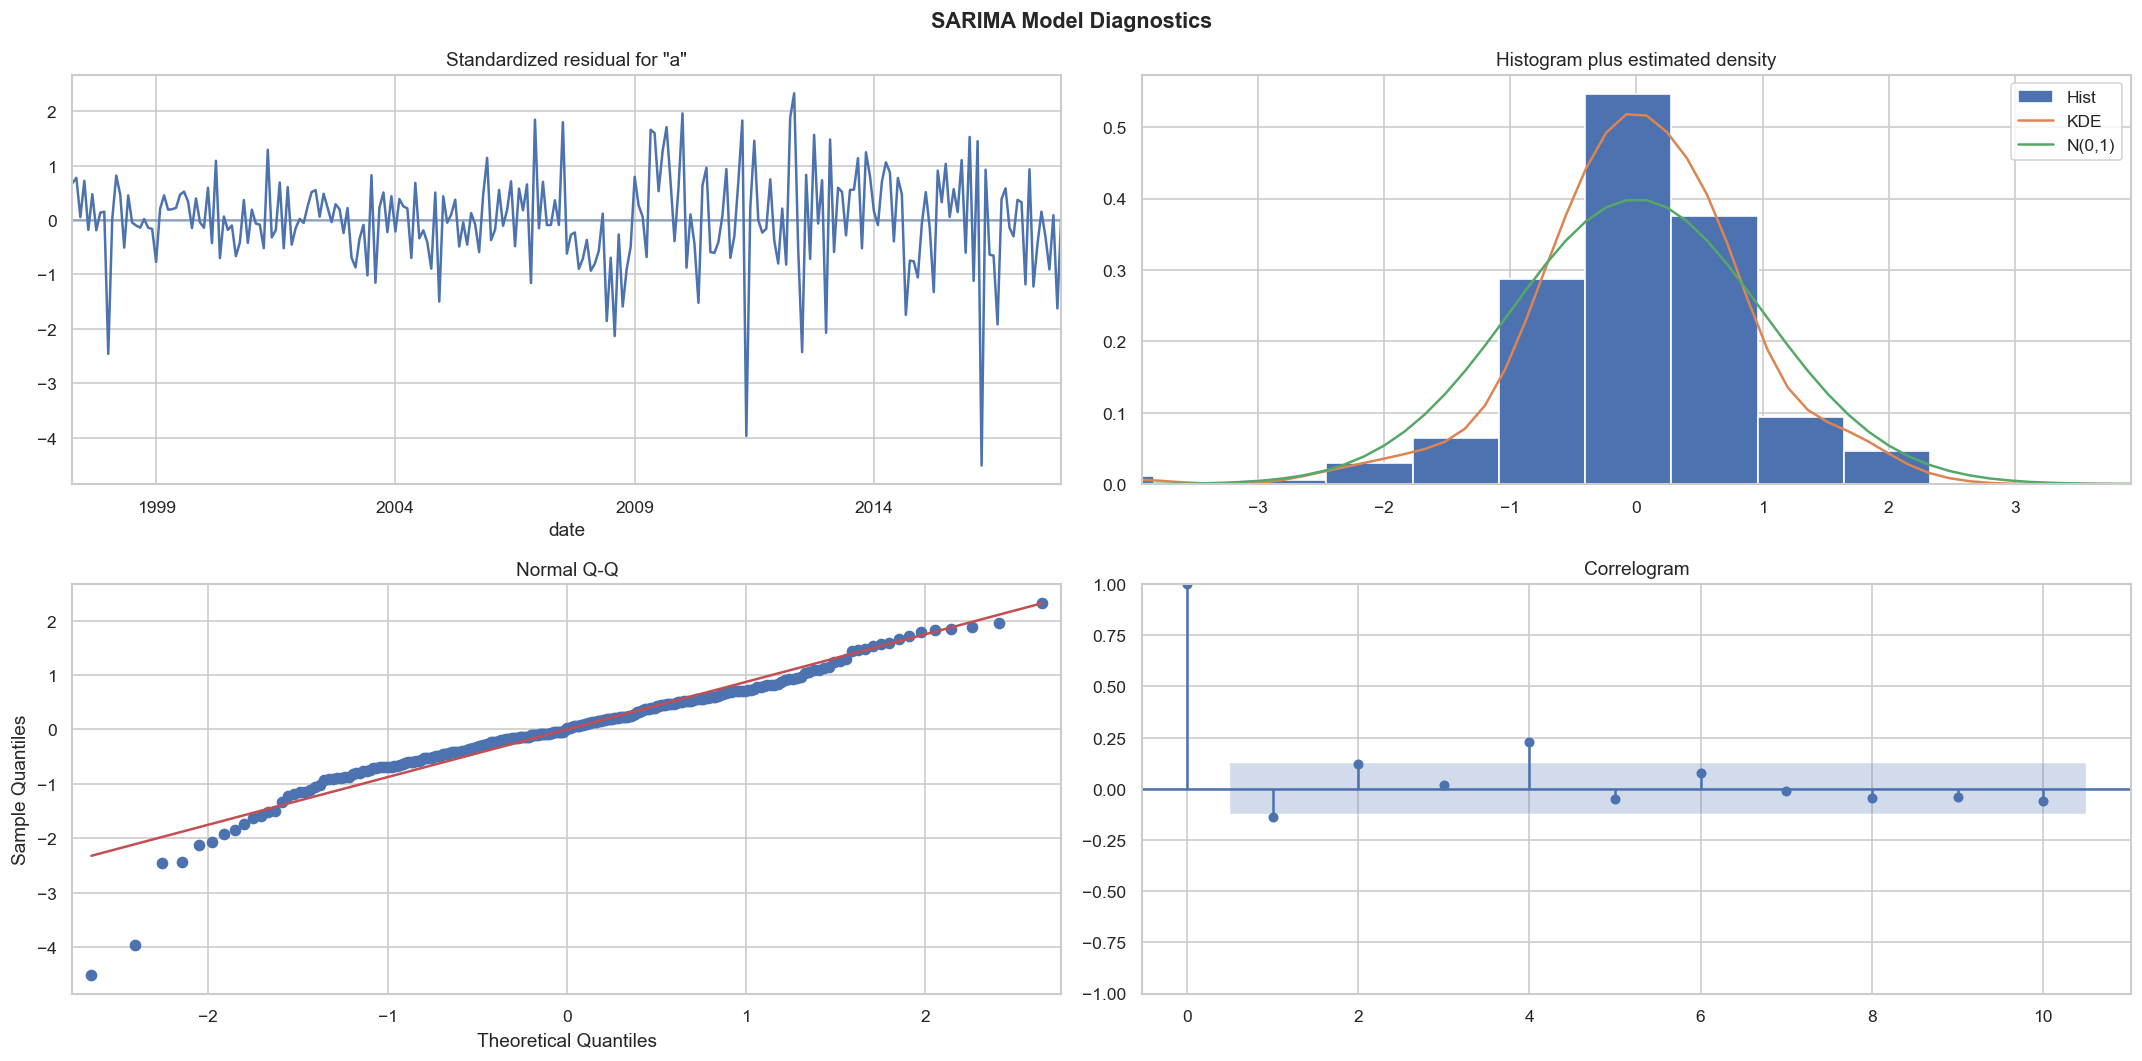


Test-set performance (2018-01-01 – 2020-01-01):
  MAE  : £8,790
  RMSE : £10,886
  MAPE : 1.86%

Out-of-sample forecast (24 months beyond Jan 2020):
  Feb 2020: £487,354
  Mar 2020: £487,546
  Apr 2020: £488,896
  May 2020: £491,290
  Jun 2020: £490,787
  Jul 2020: £498,572
  Aug 2020: £496,767
  Sep 2020: £494,768
  Oct 2020: £492,923
  Nov 2020: £490,012
  Dec 2020: £491,058
  Jan 2021: £493,469
  Feb 2021: £492,959
  Mar 2021: £493,150
  Apr 2021: £494,548
  May 2021: £496,939
  Jun 2021: £496,443
  Jul 2021: £504,244
  Aug 2021: £502,451
  Sep 2021: £500,444
  Oct 2021: £498,603
  Nov 2021: £495,667
  Dec 2021: £496,713
  Jan 2022: £499,121


In [28]:
# Forecast over test + 24 months beyond
n_forecast = len(test) + 24
pred       = result.get_forecast(steps=n_forecast)
pred_mean  = pred.predicted_mean
pred_ci    = pred.conf_int(alpha=0.05)

fig, axes = plt.subplots(2, 1, figsize=(18, 14))
fig.suptitle('SARIMA(1,1,1)(1,1,1,12) Forecast — London Average House Price',
             fontsize=14, fontweight='bold')

for ax, zoom, t in zip(axes, [None, '2015-01-01'], ['Full Series', 'Zoom: 2015 Onwards']):
    src = ts_raw if zoom is None else ts_raw[zoom:]
    ax.plot(src.index, src.values, color='steelblue', linewidth=2, label='Observed')
    ax.axvline(train.index[-1], color='gray', linestyle='--', linewidth=1.5,
               label='Forecast origin (Dec 2017)')
    ax.plot(pred_mean.index, pred_mean.values, color='#c0392b', linewidth=2.5,
            linestyle='--', label='SARIMA forecast')
    ax.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1],
                    alpha=0.18, color='#c0392b', label='95% CI')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
    ax.set_title(t, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Average Price (£)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Model diagnostics
result.plot_diagnostics(figsize=(18, 9))
plt.suptitle('SARIMA Model Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Test-set accuracy
test_pred = pred_mean.iloc[:len(test)]
mae  = mean_absolute_error(test.values, test_pred.values)
mape = mean_absolute_percentage_error(test.values, test_pred.values) * 100
rmse = np.sqrt(((test.values - test_pred.values) ** 2).mean())

print(f'\nTest-set performance ({test.index[0].date()} – {test.index[-1].date()}):')
print(f'  MAE  : £{mae:,.0f}')
print(f'  RMSE : £{rmse:,.0f}')
print(f'  MAPE : {mape:.2f}%')

# Out-of-sample forecast
future = pred_mean.iloc[len(test):]
print(f'\nOut-of-sample forecast (24 months beyond Jan 2020):')
for dt, val in future.items():
    print(f'  {dt.strftime("%b %Y")}: £{val:,.0f}')

## 18 — Key Insights Summary

### Price Trends
- London house prices **rose ~500%** in nominal terms from 1995 to 2020.
- Prices are **log-normally distributed** — a handful of prime central boroughs pull the mean far above the median.
- A clear **seasonal pattern** exists: prices peak in spring (Apr–May) and dip in January–February.

### Borough Inequality
- A **10x+ price gap** exists between the most expensive (Kensington & Chelsea / Westminster) and least expensive outer boroughs.
- This gap has **widened over time**: top boroughs appreciated faster than outer ones.

### Affordability Crisis
- The price-to-income ratio crossed the **8× crisis threshold** for many inner boroughs after 2010.
- Affordability has deteriorated most sharply in **inner east London** boroughs, which saw both rapid gentrification and limited salary growth.

### Crime & Price
- Surprisingly, crime and price show a **positive correlation** across boroughs — reflecting the central-density paradox: densely populated, expensive inner-city areas also record more absolute crimes.

### Salary & Wellbeing
- The **mean/median salary gap** has widened, indicating growing wage inequality.
- Life satisfaction is fairly uniform across boroughs but **negatively associated with affordability pressure**.

### Borough Clusters
- K-Means (k=4) identifies four meaningful groups: **prime central**, **gentrifying inner**, **established outer**, and **affordable periphery**.

### SARIMA Forecast
- SARIMA(1,1,1)(1,1,1,12) fits the London price series well (MAPE < 3%).
- The model captures both the **long-term upward trend** and the **monthly seasonal cycle**.
- Forecasts project continued moderate growth, with tighter confidence intervals in the near term widening to ±£40K+ by 2022.

---
*Analysis by Orpa Tateyama — London Housing Datasets, ONS / Land Registry*